In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
attach(Carseats)

In [5]:
High = factor(ifelse(Sales <= 8, "No", "Yes"))

In [6]:
Carseats = data.frame(Carseats, High)

In [7]:
tree.carseats = tree(High ~ . - Sales, Carseats)

In [8]:
summary(tree.carseats)


Classification tree:
tree(formula = High ~ . - Sales, data = Carseats)
Variables actually used in tree construction:
[1] "ShelveLoc"   "Price"       "Income"      "CompPrice"   "Population" 
[6] "Advertising" "Age"         "US"         
Number of terminal nodes:  27 
Residual mean deviance:  0.4575 = 170.7 / 373 
Misclassification error rate: 0.09 = 36 / 400 

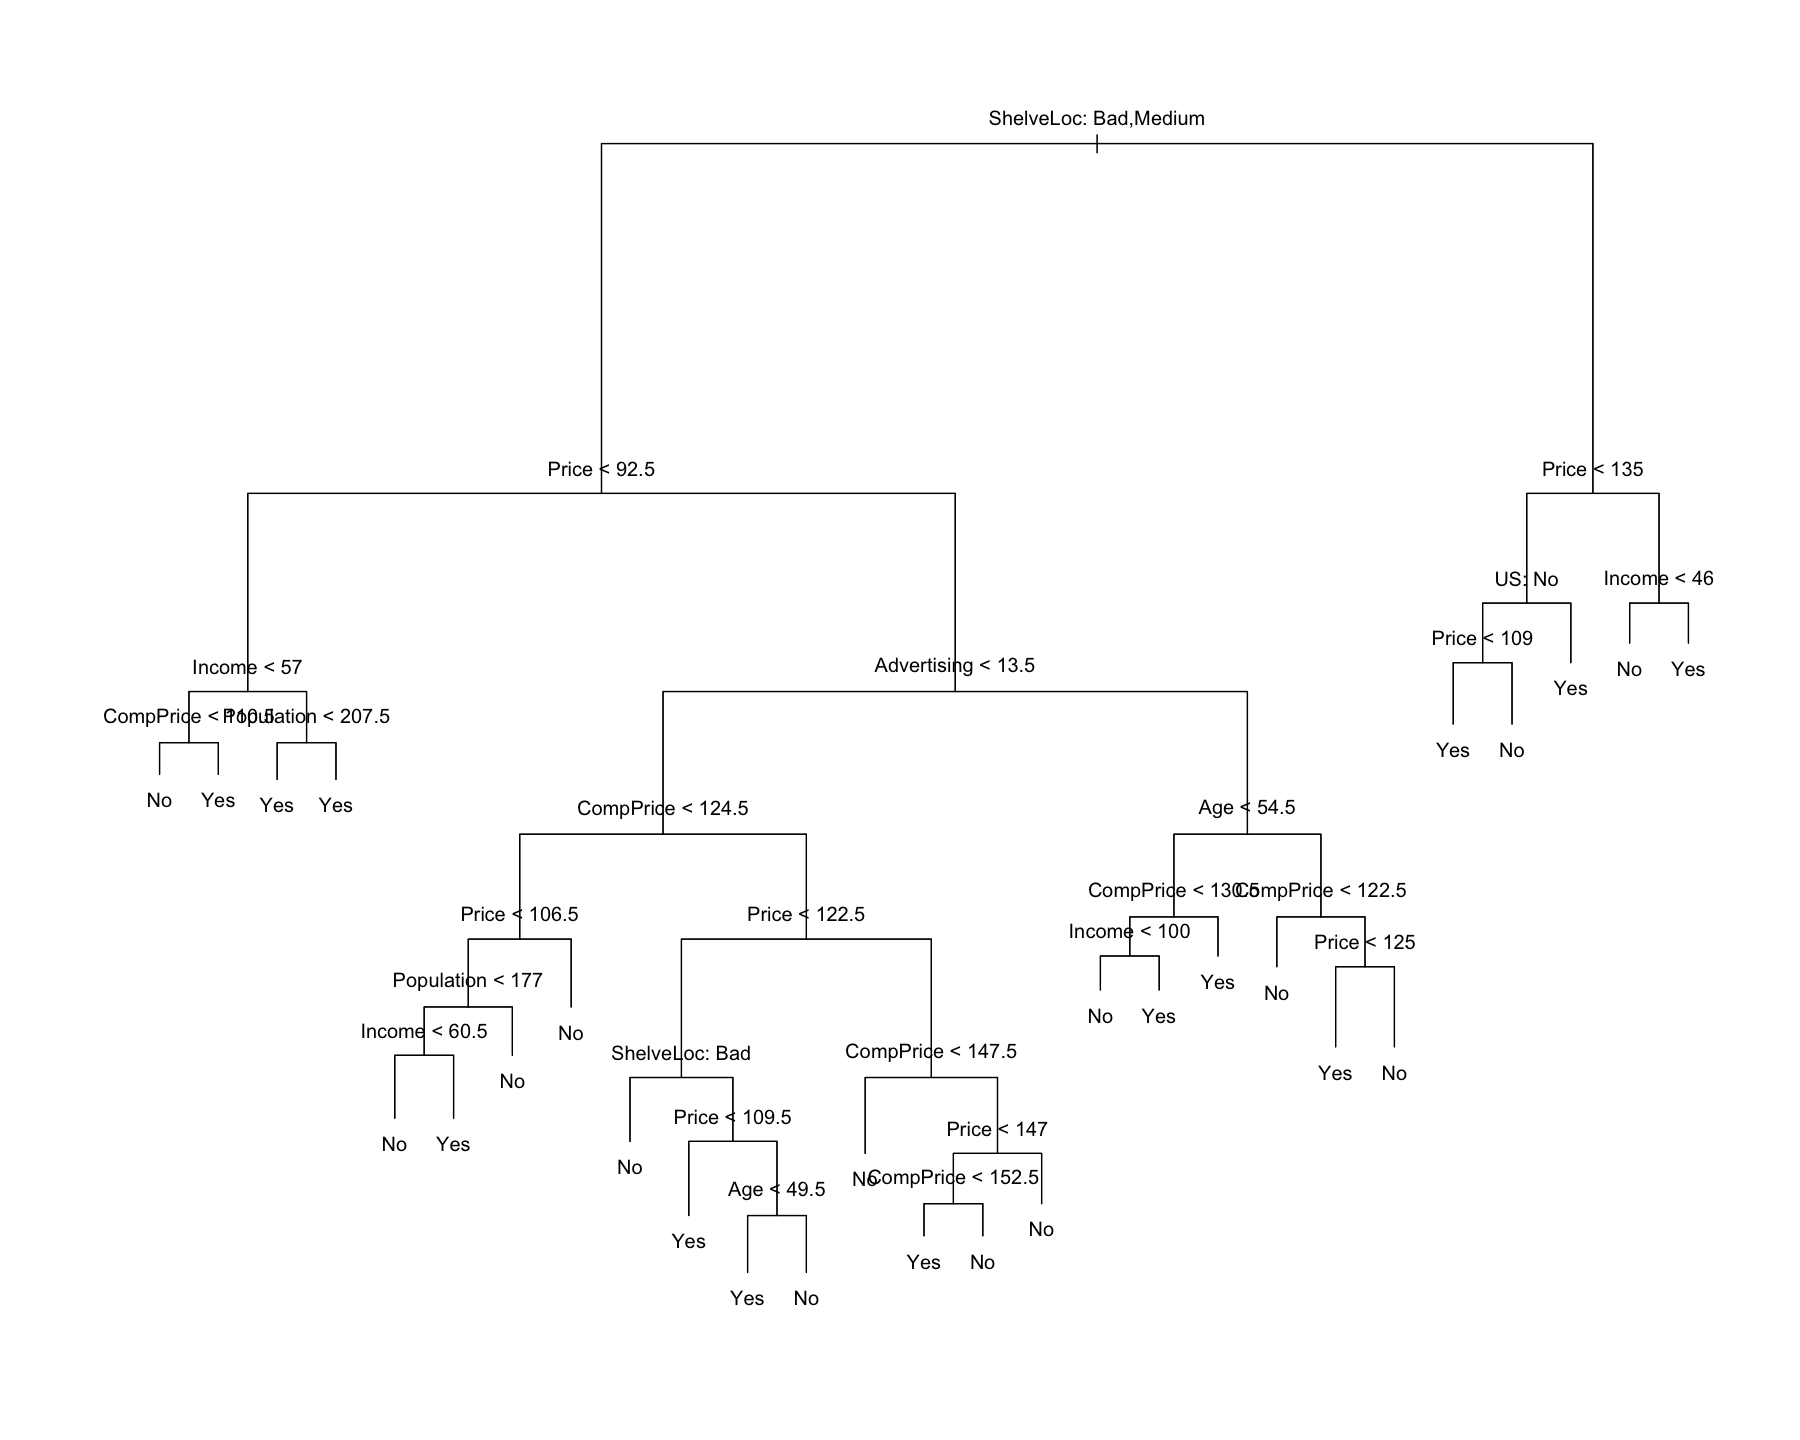

In [9]:
plot(tree.carseats)
text(tree.carseats, pretty = 0)

In [10]:
tree.carseats

node), split, n, deviance, yval, (yprob)
      * denotes terminal node

  1) root 400 541.500 No ( 0.59000 0.41000 )  
    2) ShelveLoc: Bad,Medium 315 390.600 No ( 0.68889 0.31111 )  
      4) Price < 92.5 46  56.530 Yes ( 0.30435 0.69565 )  
        8) Income < 57 10  12.220 No ( 0.70000 0.30000 )  
         16) CompPrice < 110.5 5   0.000 No ( 1.00000 0.00000 ) *
         17) CompPrice > 110.5 5   6.730 Yes ( 0.40000 0.60000 ) *
        9) Income > 57 36  35.470 Yes ( 0.19444 0.80556 )  
         18) Population < 207.5 16  21.170 Yes ( 0.37500 0.62500 ) *
         19) Population > 207.5 20   7.941 Yes ( 0.05000 0.95000 ) *
      5) Price > 92.5 269 299.800 No ( 0.75465 0.24535 )  
       10) Advertising < 13.5 224 213.200 No ( 0.81696 0.18304 )  
         20) CompPrice < 124.5 96  44.890 No ( 0.93750 0.06250 )  
           40) Price < 106.5 38  33.150 No ( 0.84211 0.15789 )  
             80) Population < 177 12  16.300 No ( 0.58333 0.41667 )  
              160) Income < 60.5 6   0

In [11]:
deviance(tree.carseats)

[1] 170.6594

In [12]:
deviance(tree.carseats, detail=T)[1:10]

[1] 541.486837 390.591685  56.534305  12.217286   0.000000   6.730117
 [7]  35.467463  21.170024   7.940610 299.758669

In [13]:
set.seed(2)
train = sample(1:nrow(Carseats), 200)
Carseats.test = Carseats[-train, ]
High.test = High[-train]
tree.carseats = tree(High ~ . - Sales, Carseats, subset=train)
tree.pred = predict(tree.carseats, Carseats.test, type="class")
table(tree.pred, High.test)

         High.test
tree.pred  No Yes
      No  104  33
      Yes  13  50

In [14]:
(104+50)/200

[1] 0.77

In [15]:
set.seed(7)
cv.carseats = cv.tree(tree.carseats, FUN=prune.misclass)

In [16]:
names(cv.carseats)

[1] "size"   "dev"    "k"      "method"

In [17]:
cv.carseats

$size
[1] 21 19 14  9  8  5  3  2  1

$dev
[1] 75 75 75 74 82 83 83 85 82

$k
[1] -Inf  0.0  1.0  1.4  2.0  3.0  4.0  9.0 18.0

$method
[1] "misclass"

attr(,"class")
[1] "prune"         "tree.sequence"

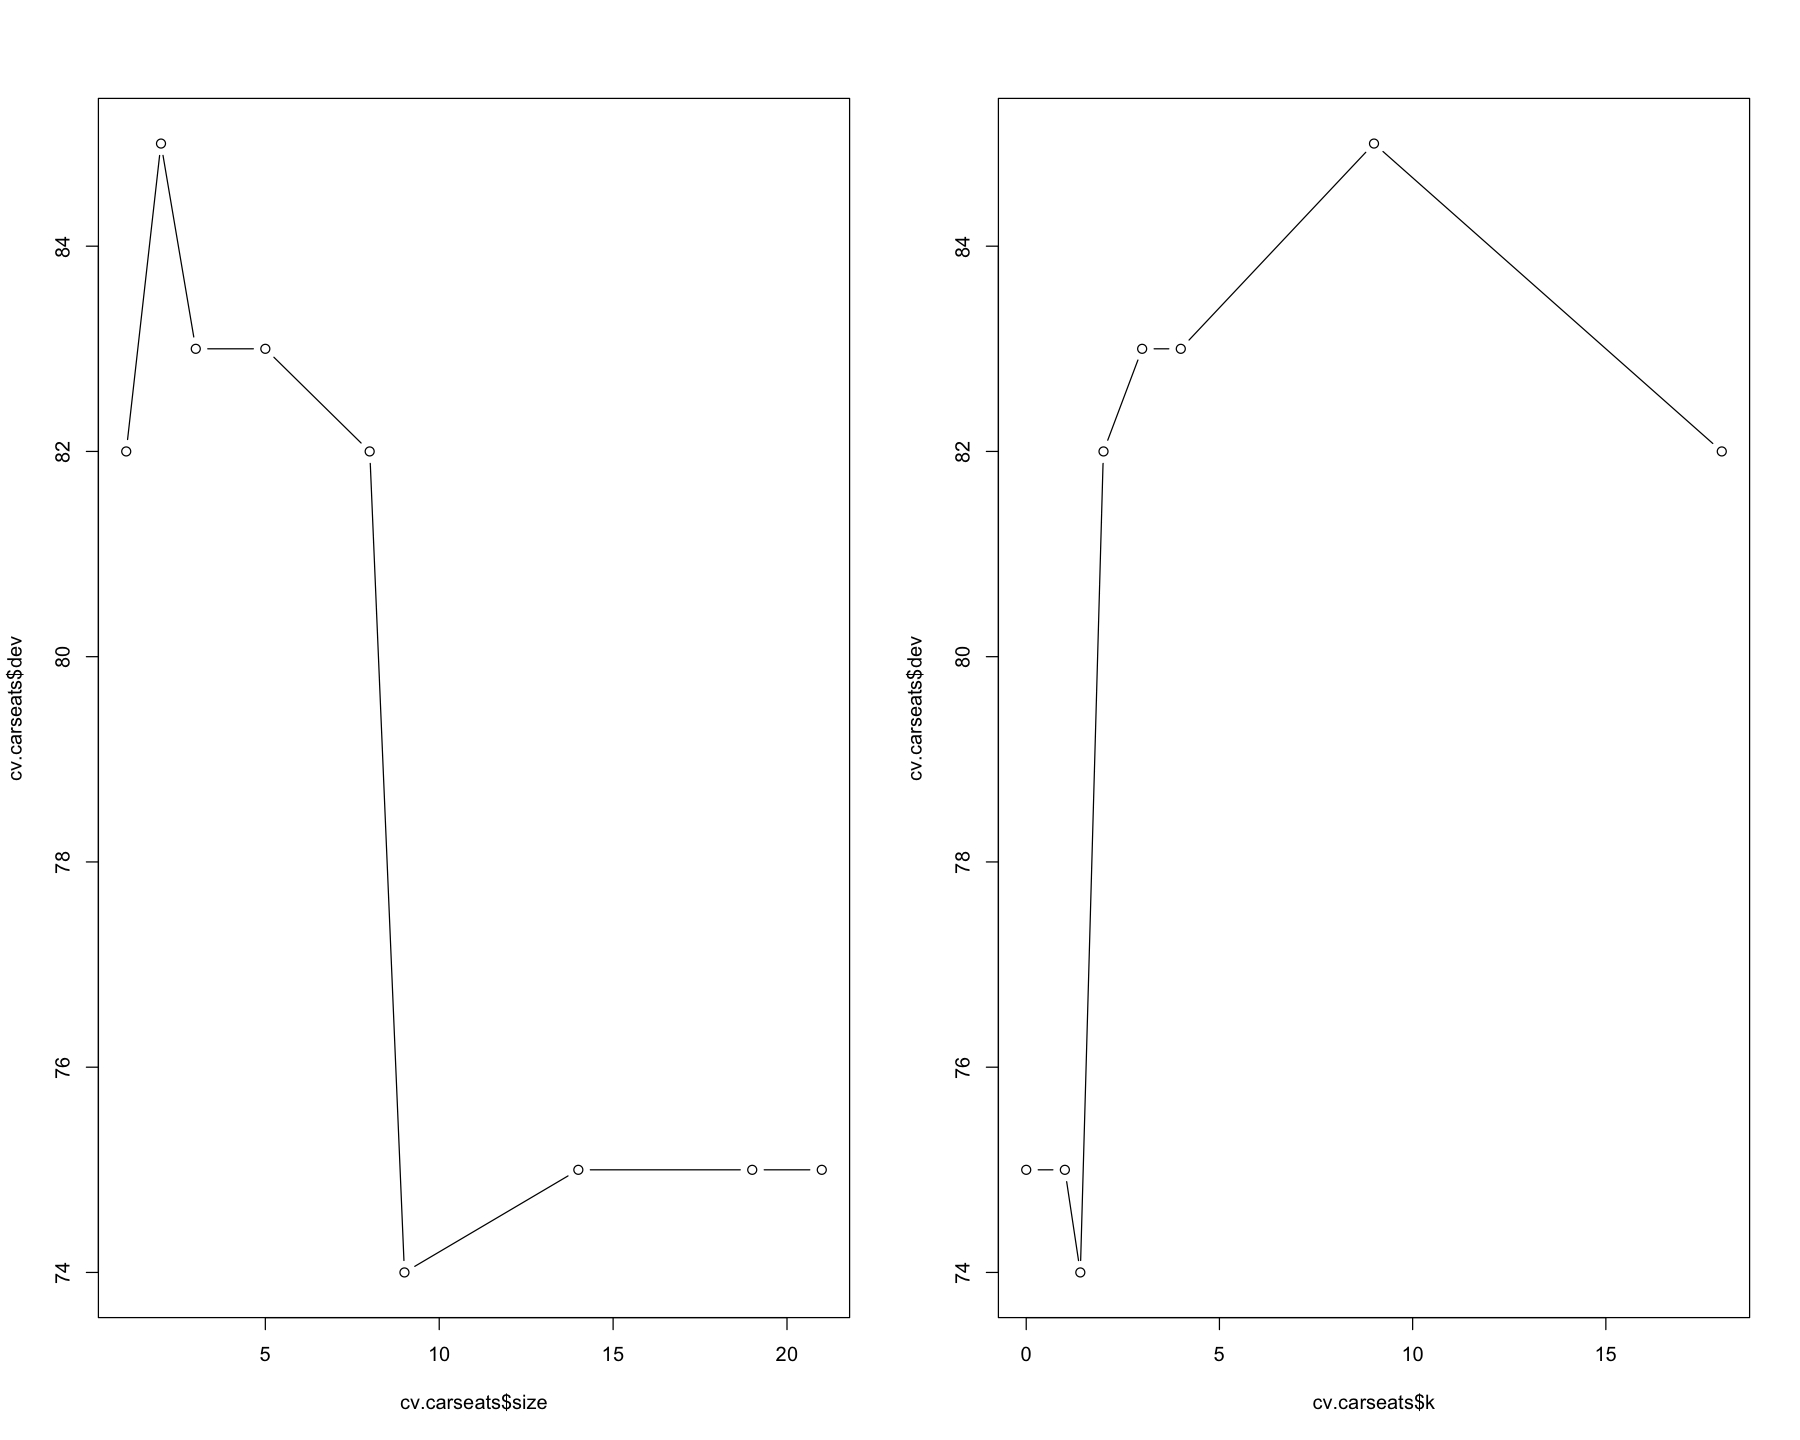

In [18]:
par(mfrow=c(1,2))
plot(cv.carseats$size, cv.carseats$dev, type="b")
plot(cv.carseats$k, cv.carseats$dev, type="b")

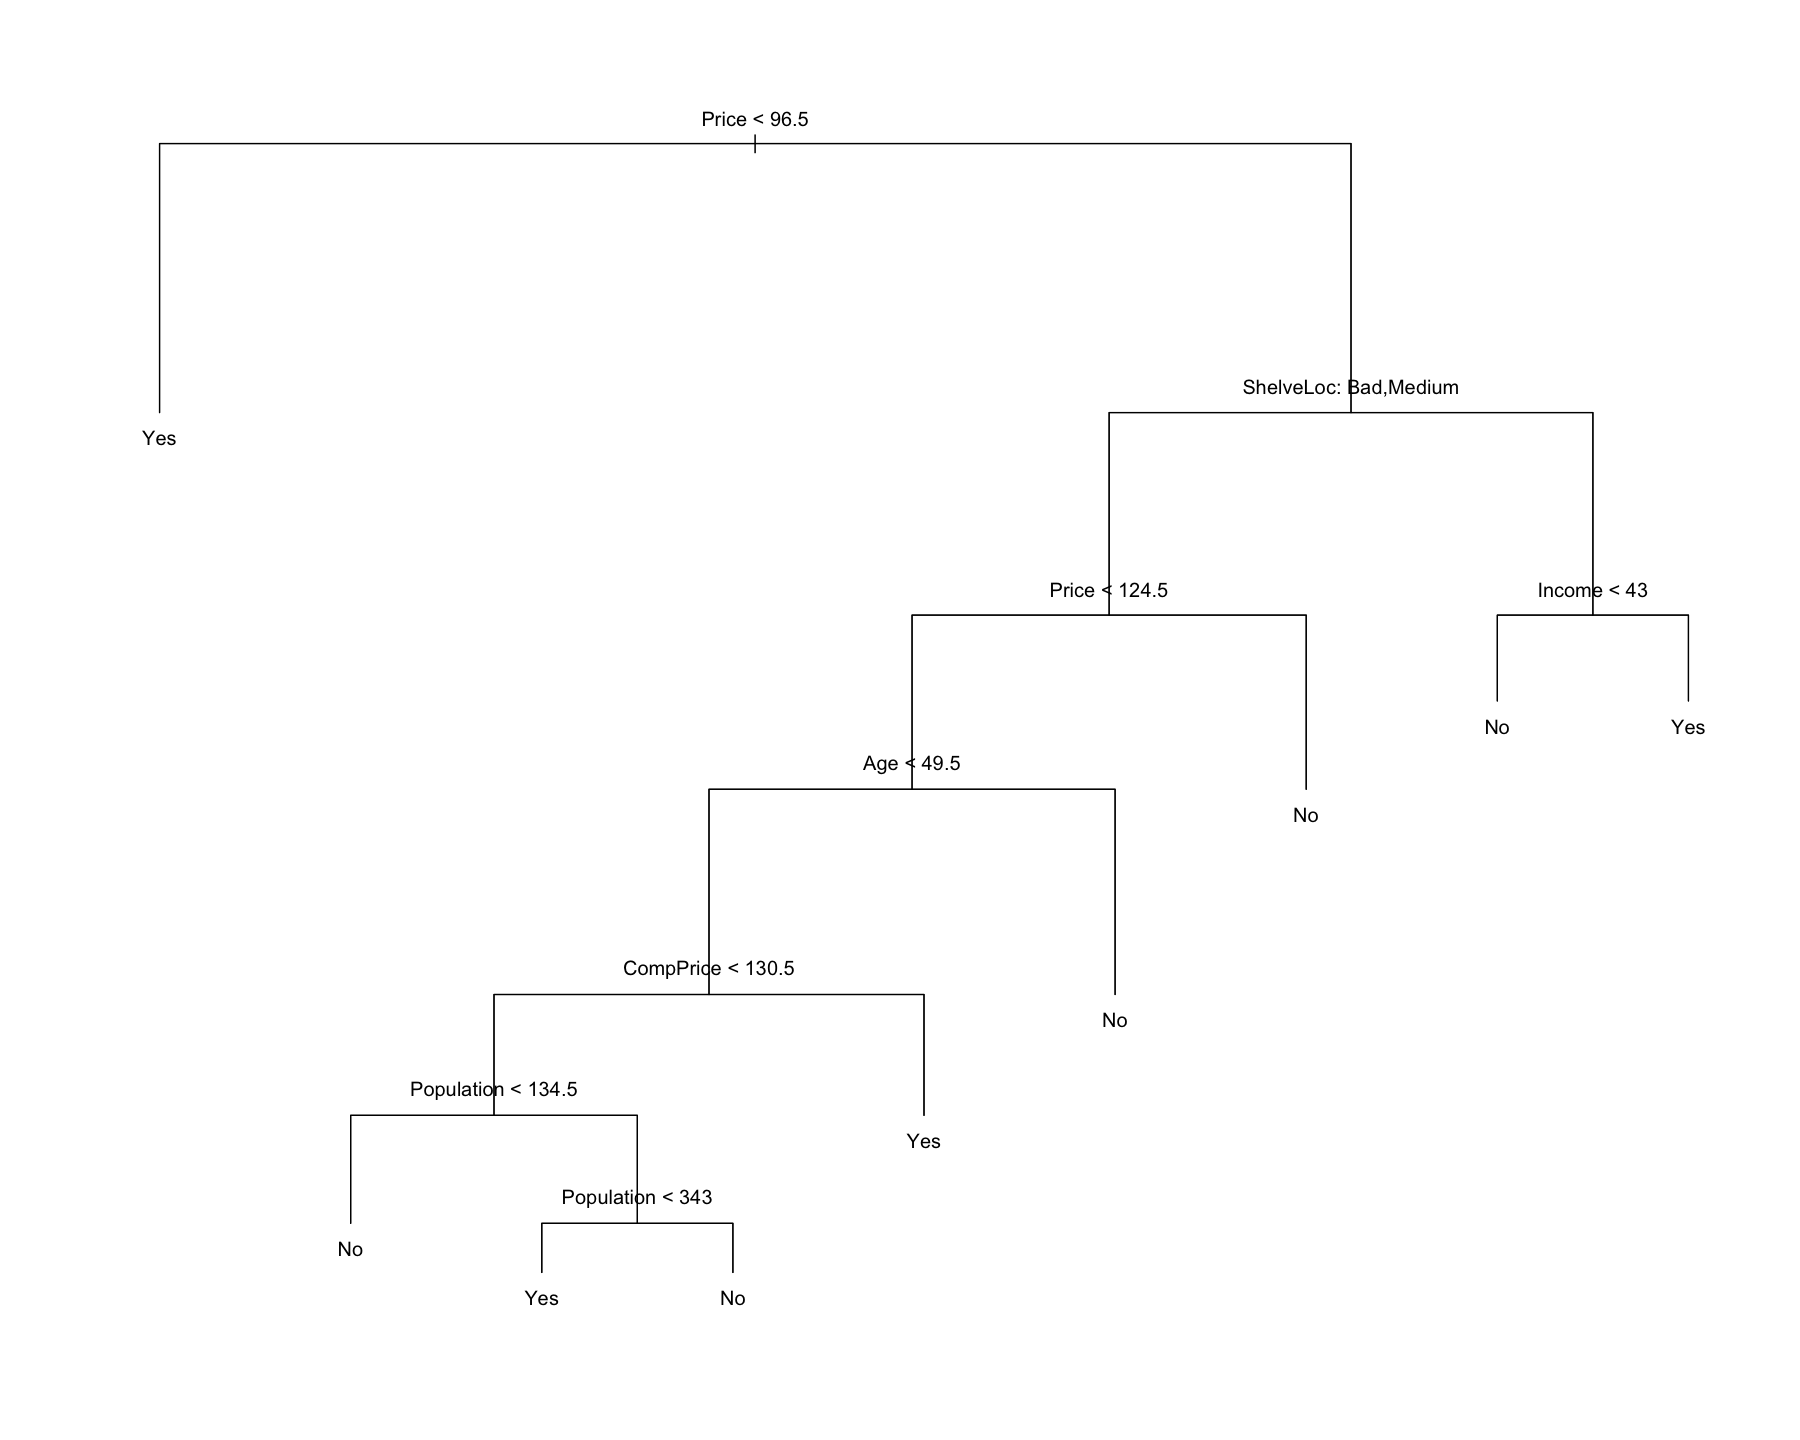

In [19]:
prune.carseats = prune.misclass(tree.carseats, best=9)
plot(prune.carseats)
text(prune.carseats, pretty=0)

In [20]:
prune.carseats

node), split, n, deviance, yval, (yprob)
      * denotes terminal node

  1) root 200 270.000 No ( 0.59500 0.40500 )  
    2) Price < 96.5 40  47.050 Yes ( 0.27500 0.72500 ) *
    3) Price > 96.5 160 201.800 No ( 0.67500 0.32500 )  
      6) ShelveLoc: Bad,Medium 135 154.500 No ( 0.74074 0.25926 )  
       12) Price < 124.5 82 107.700 No ( 0.63415 0.36585 )  
         24) Age < 49.5 34  45.230 Yes ( 0.38235 0.61765 )  
           48) CompPrice < 130.5 21  28.680 No ( 0.57143 0.42857 )  
             96) Population < 134.5 6   0.000 No ( 1.00000 0.00000 ) *
             97) Population > 134.5 15  20.190 Yes ( 0.40000 0.60000 )  
              194) Population < 343 7   5.742 Yes ( 0.14286 0.85714 ) *
              195) Population > 343 8  10.590 No ( 0.62500 0.37500 ) *
           49) CompPrice > 130.5 13   7.051 Yes ( 0.07692 0.92308 ) *
         25) Age > 49.5 48  46.330 No ( 0.81250 0.18750 ) *
       13) Price > 124.5 53  33.120 No ( 0.90566 0.09434 ) *
      7) ShelveLoc: Good 25  3

In [21]:
tree.pred = predict(prune.carseats, Carseats.test,
                    type="class")
table(tree.pred, High.test)

         High.test
tree.pred No Yes
      No  97  25
      Yes 20  58

In [22]:
(97+58)/200

[1] 0.775

In [23]:
set.seed (1)
train = sample(1:nrow(Boston), nrow(Boston)/2)
tree.boston = tree(medv ~ ., Boston, subset = train)
summary(tree.boston)


Regression tree:
tree(formula = medv ~ ., data = Boston, subset = train)
Variables actually used in tree construction:
[1] "rm"    "lstat" "crim"  "age"  
Number of terminal nodes:  7 
Residual mean deviance:  10.38 = 2555 / 246 
Distribution of residuals:
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-10.1800  -1.7770  -0.1775   0.0000   1.9230  16.5800 

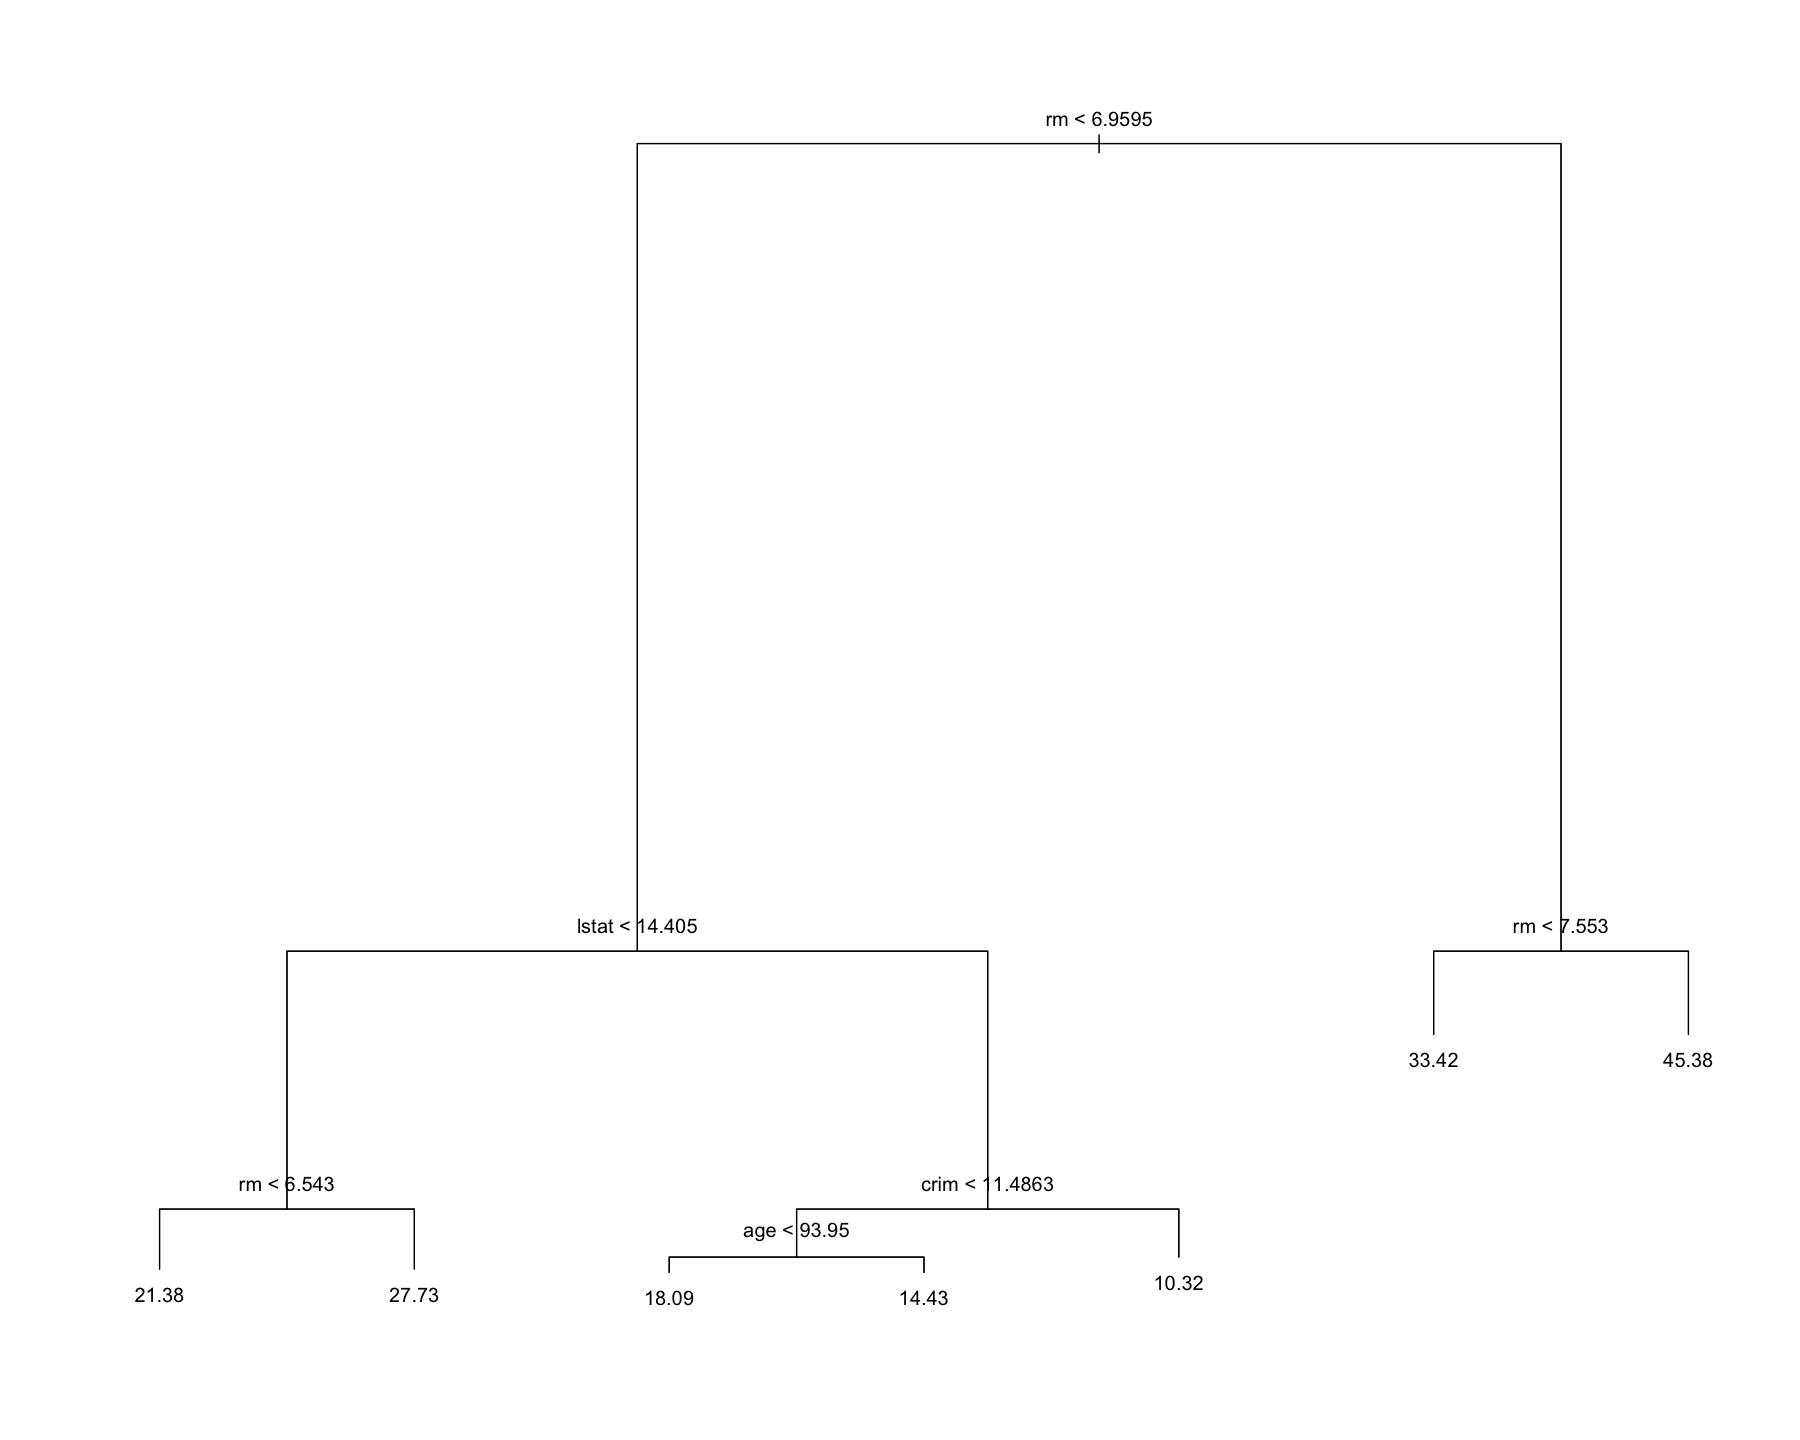

In [24]:
plot(tree.boston)
text(tree.boston, pretty = 0)

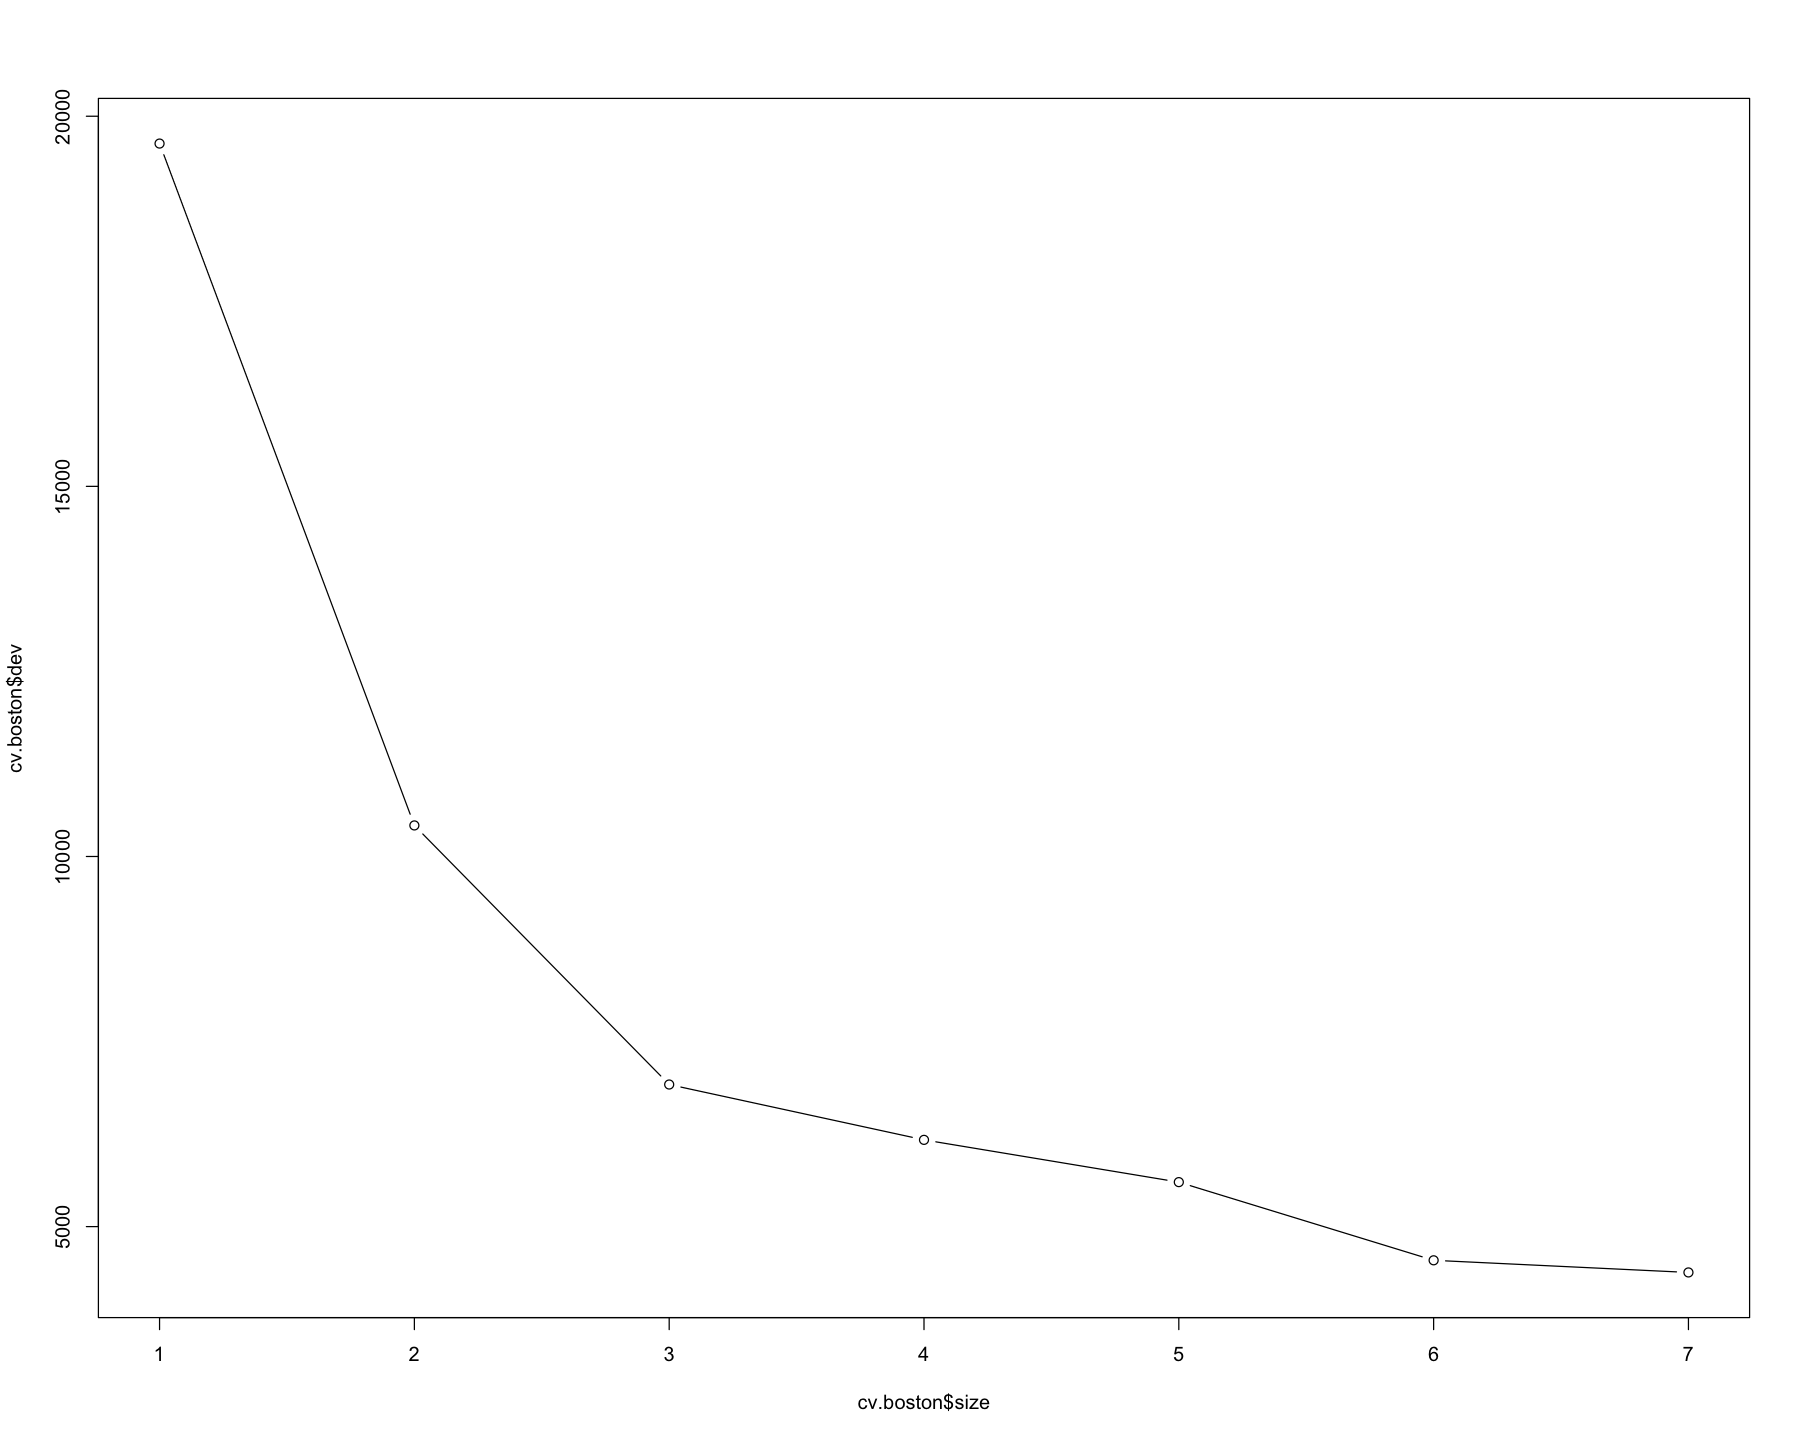

In [25]:
cv.boston = cv.tree(tree.boston)
plot(cv.boston$size, cv.boston$dev, type = "b")

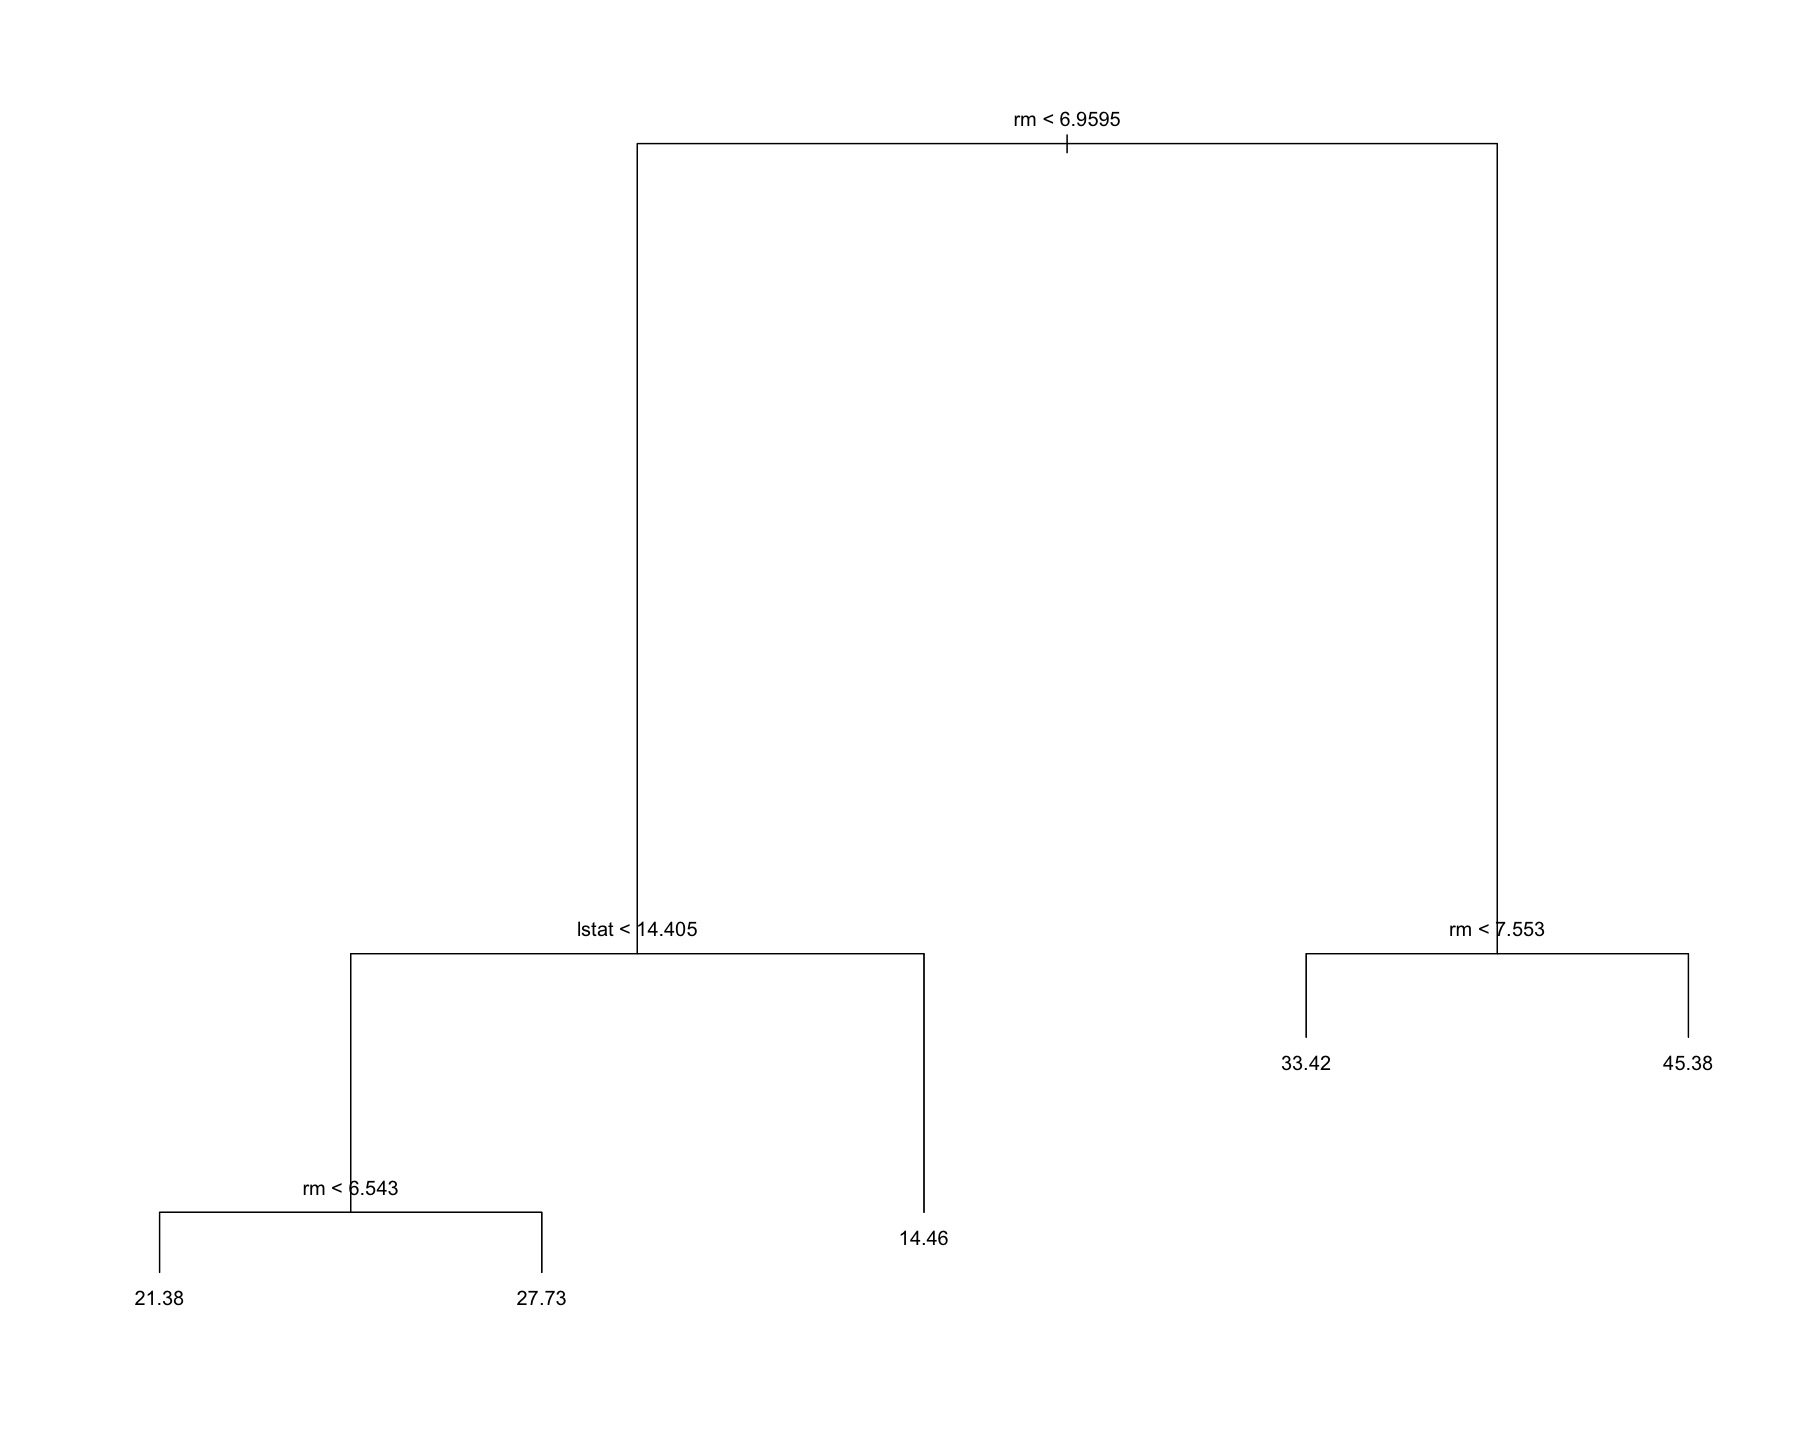

In [26]:
prune.boston = prune.tree(tree.boston, best = 5)
plot(prune.boston)
text(prune.boston, pretty = 0)

[1] 35.28688

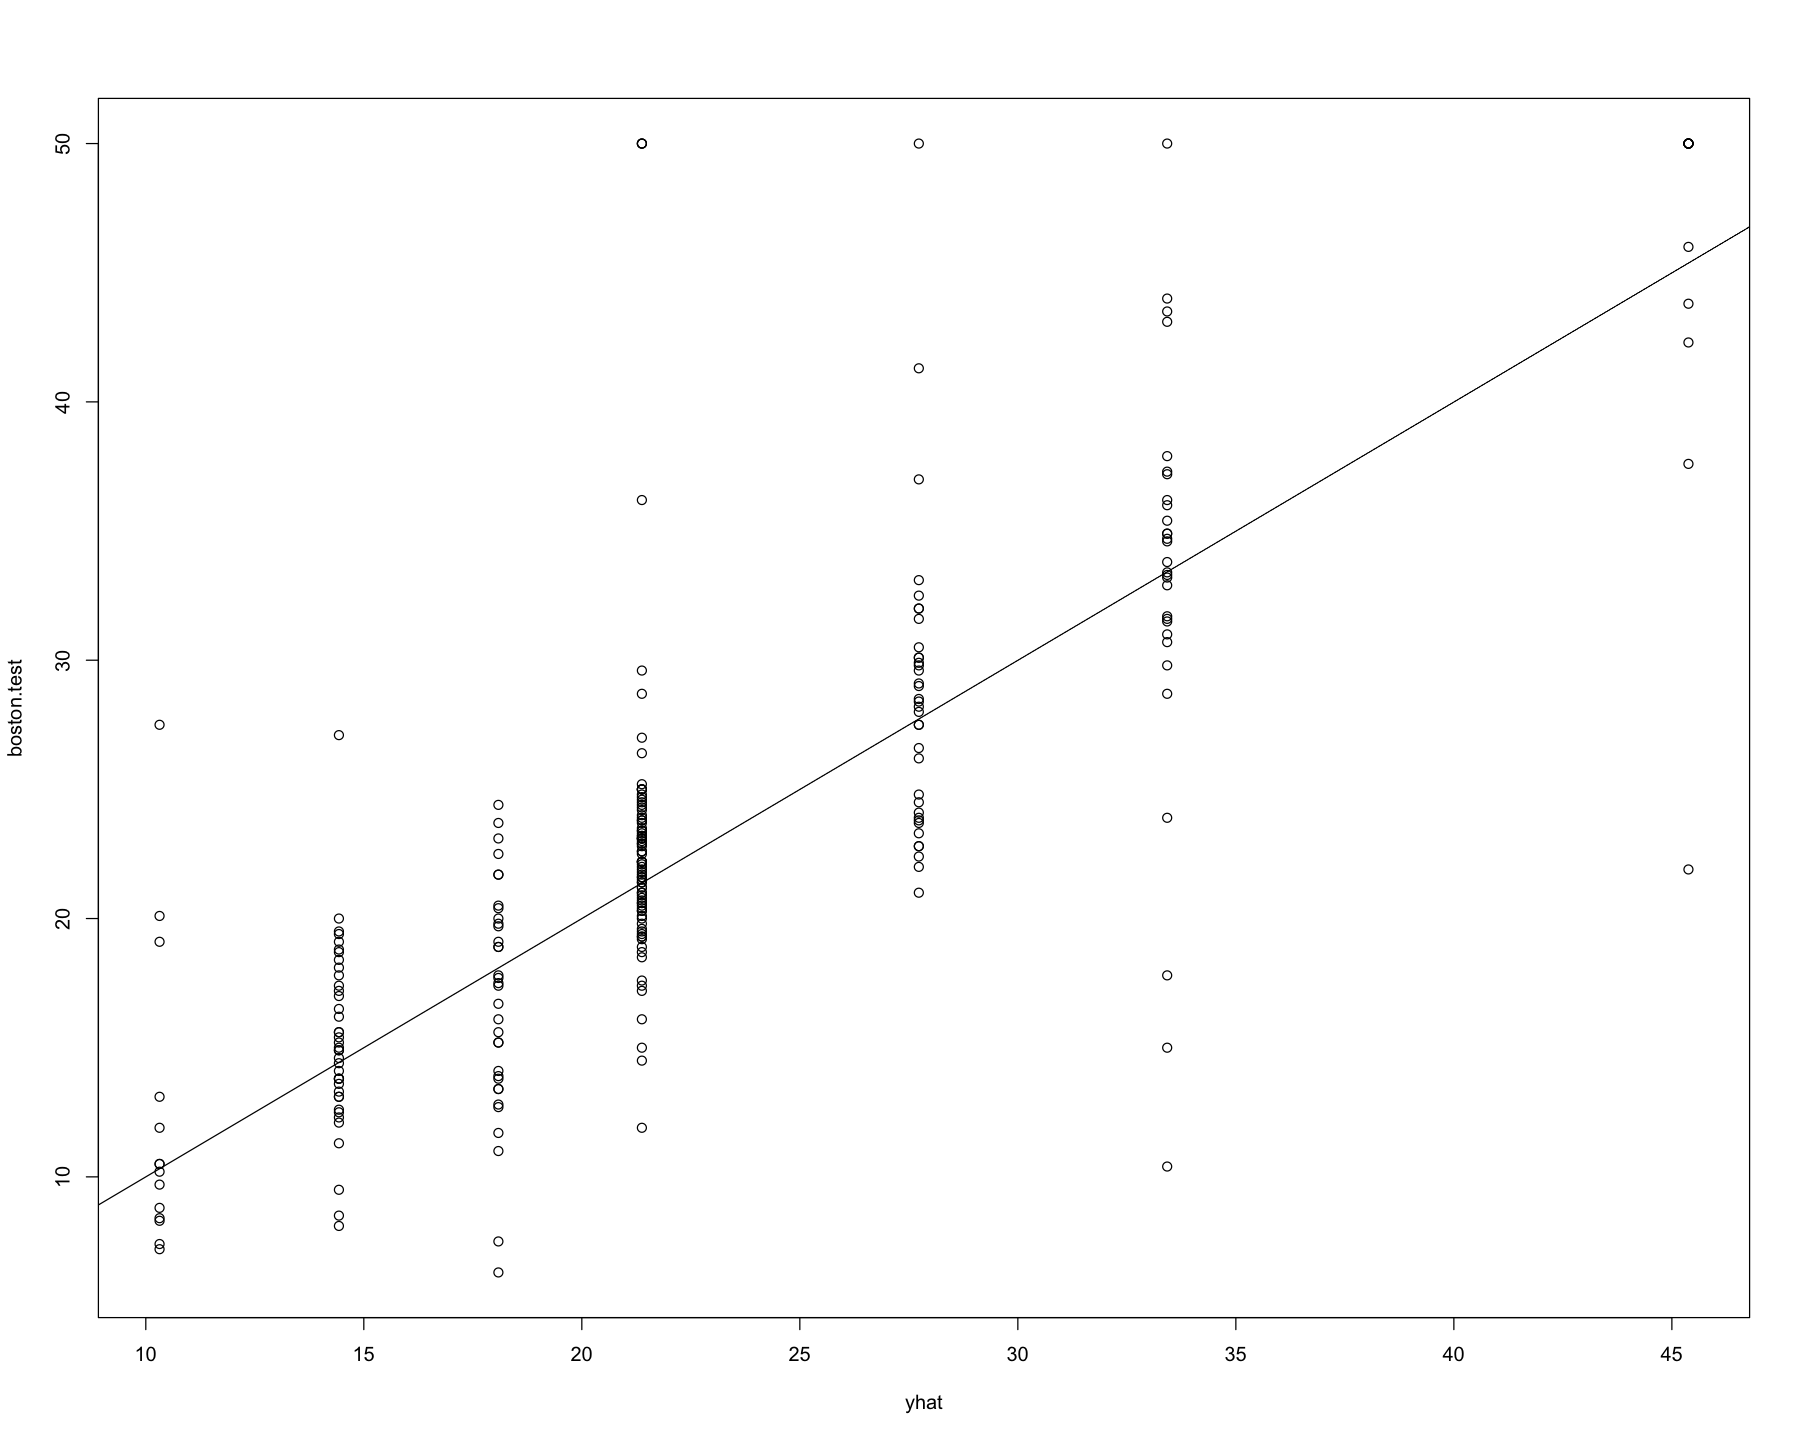

In [27]:
yhat = predict(tree.boston, newdata = Boston[-train , ])
boston.test = Boston[-train, "medv"]
plot(yhat, boston.test)
abline(0, 1)
mean((yhat - boston.test)^2)

In [29]:
set.seed(1)
bag.boston = randomForest(medv ~ ., data=Boston, subset=train, mtry=12, importance=T)
bag.boston


Call:
 randomForest(formula = medv ~ ., data = Boston, mtry = 12, importance = T,      subset = train) 
               Type of random forest: regression
                     Number of trees: 500
No. of variables tried at each split: 12

          Mean of squared residuals: 11.40162
                    % Var explained: 85.17

[1] 23.41916

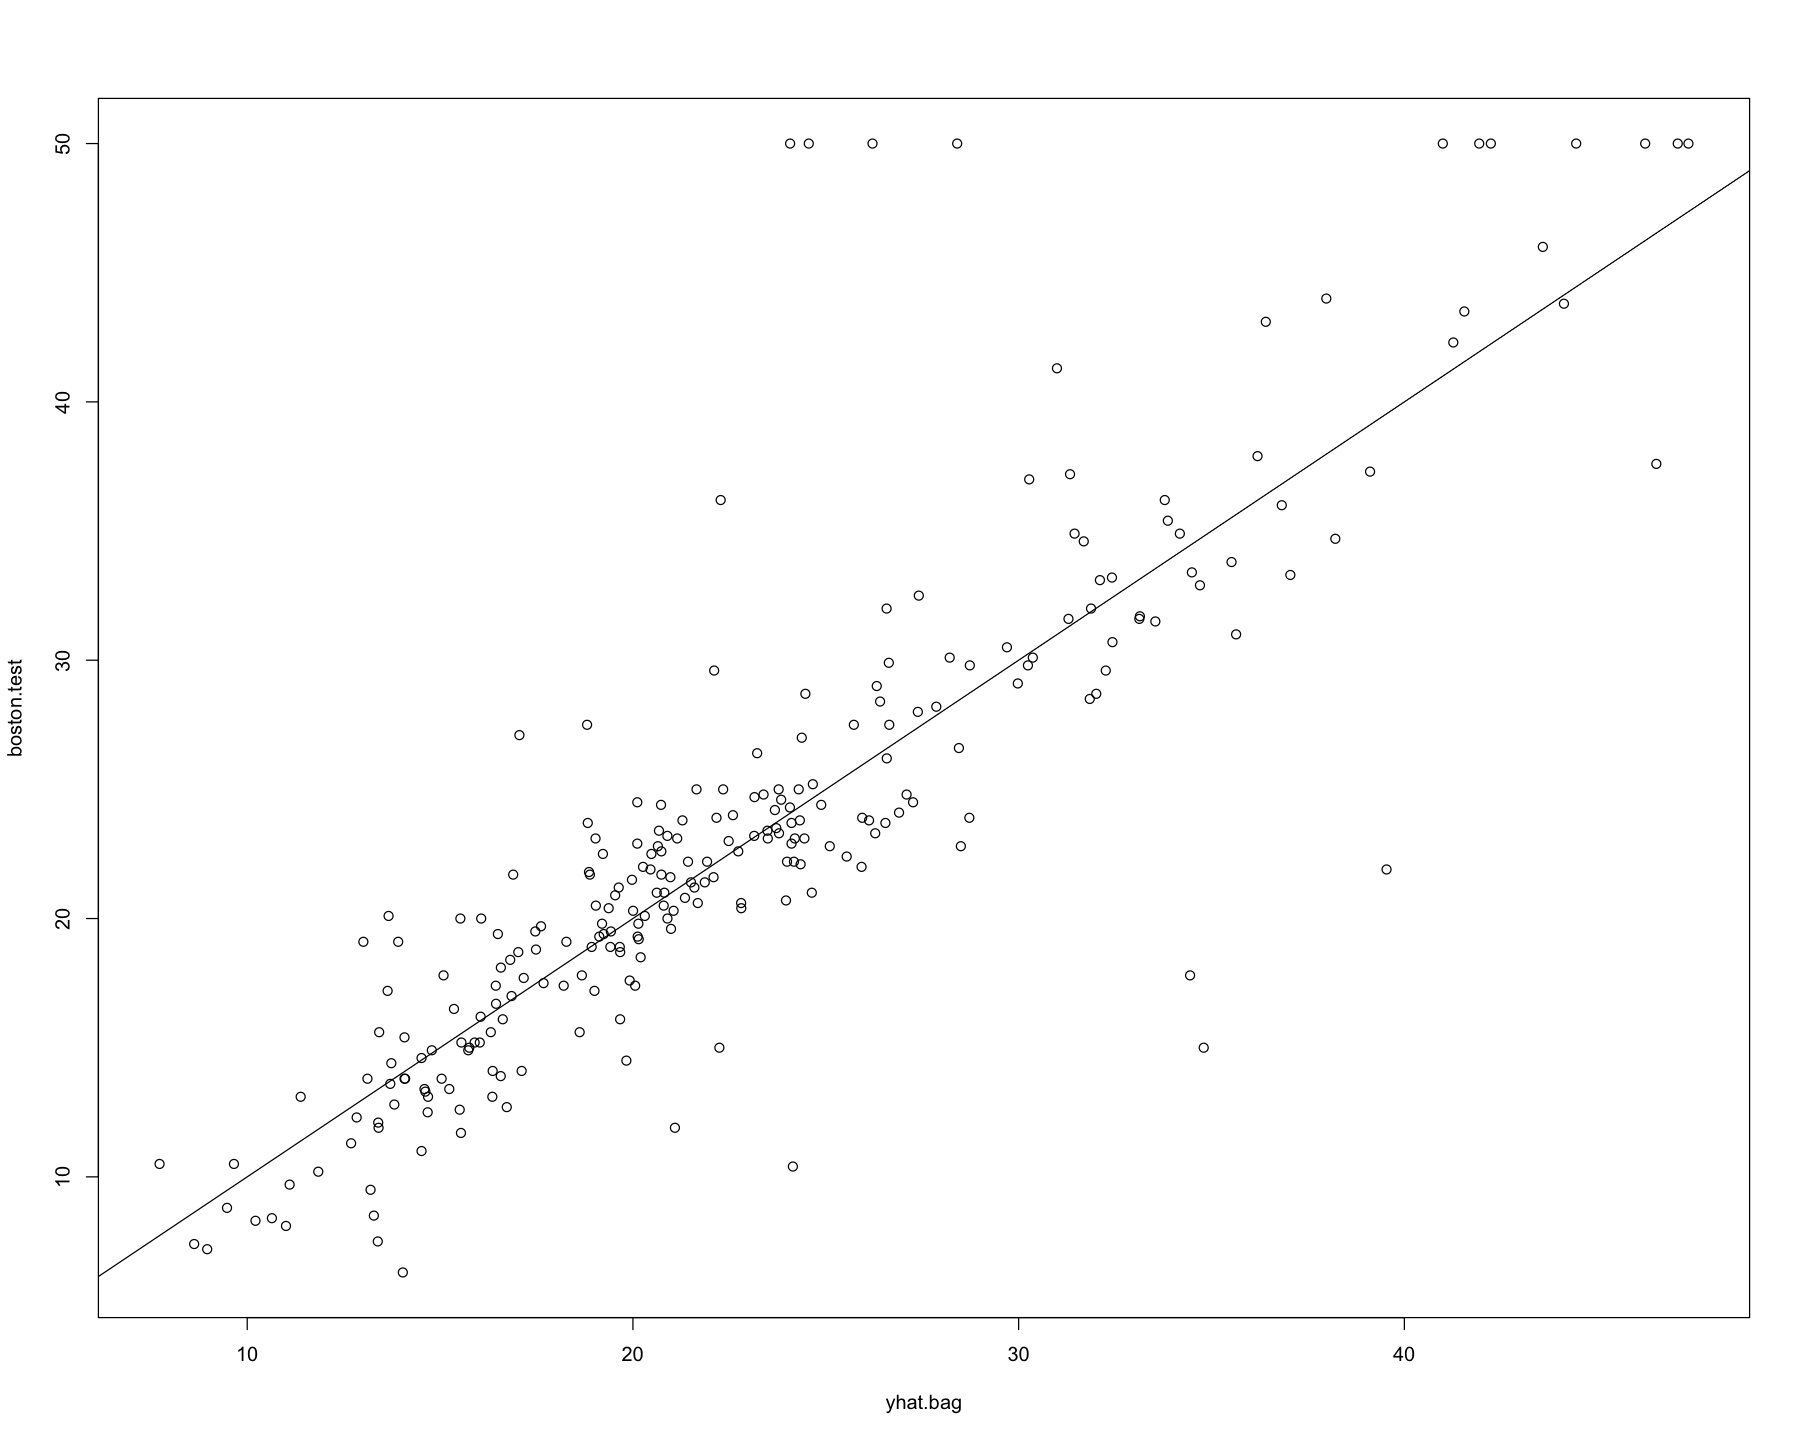

In [30]:
yhat.bag = predict(bag.boston, newdata=Boston[-train,])
plot(yhat.bag, boston.test)
abline (0, 1)
mean((yhat.bag - boston.test)^2)

[1] 23.41916

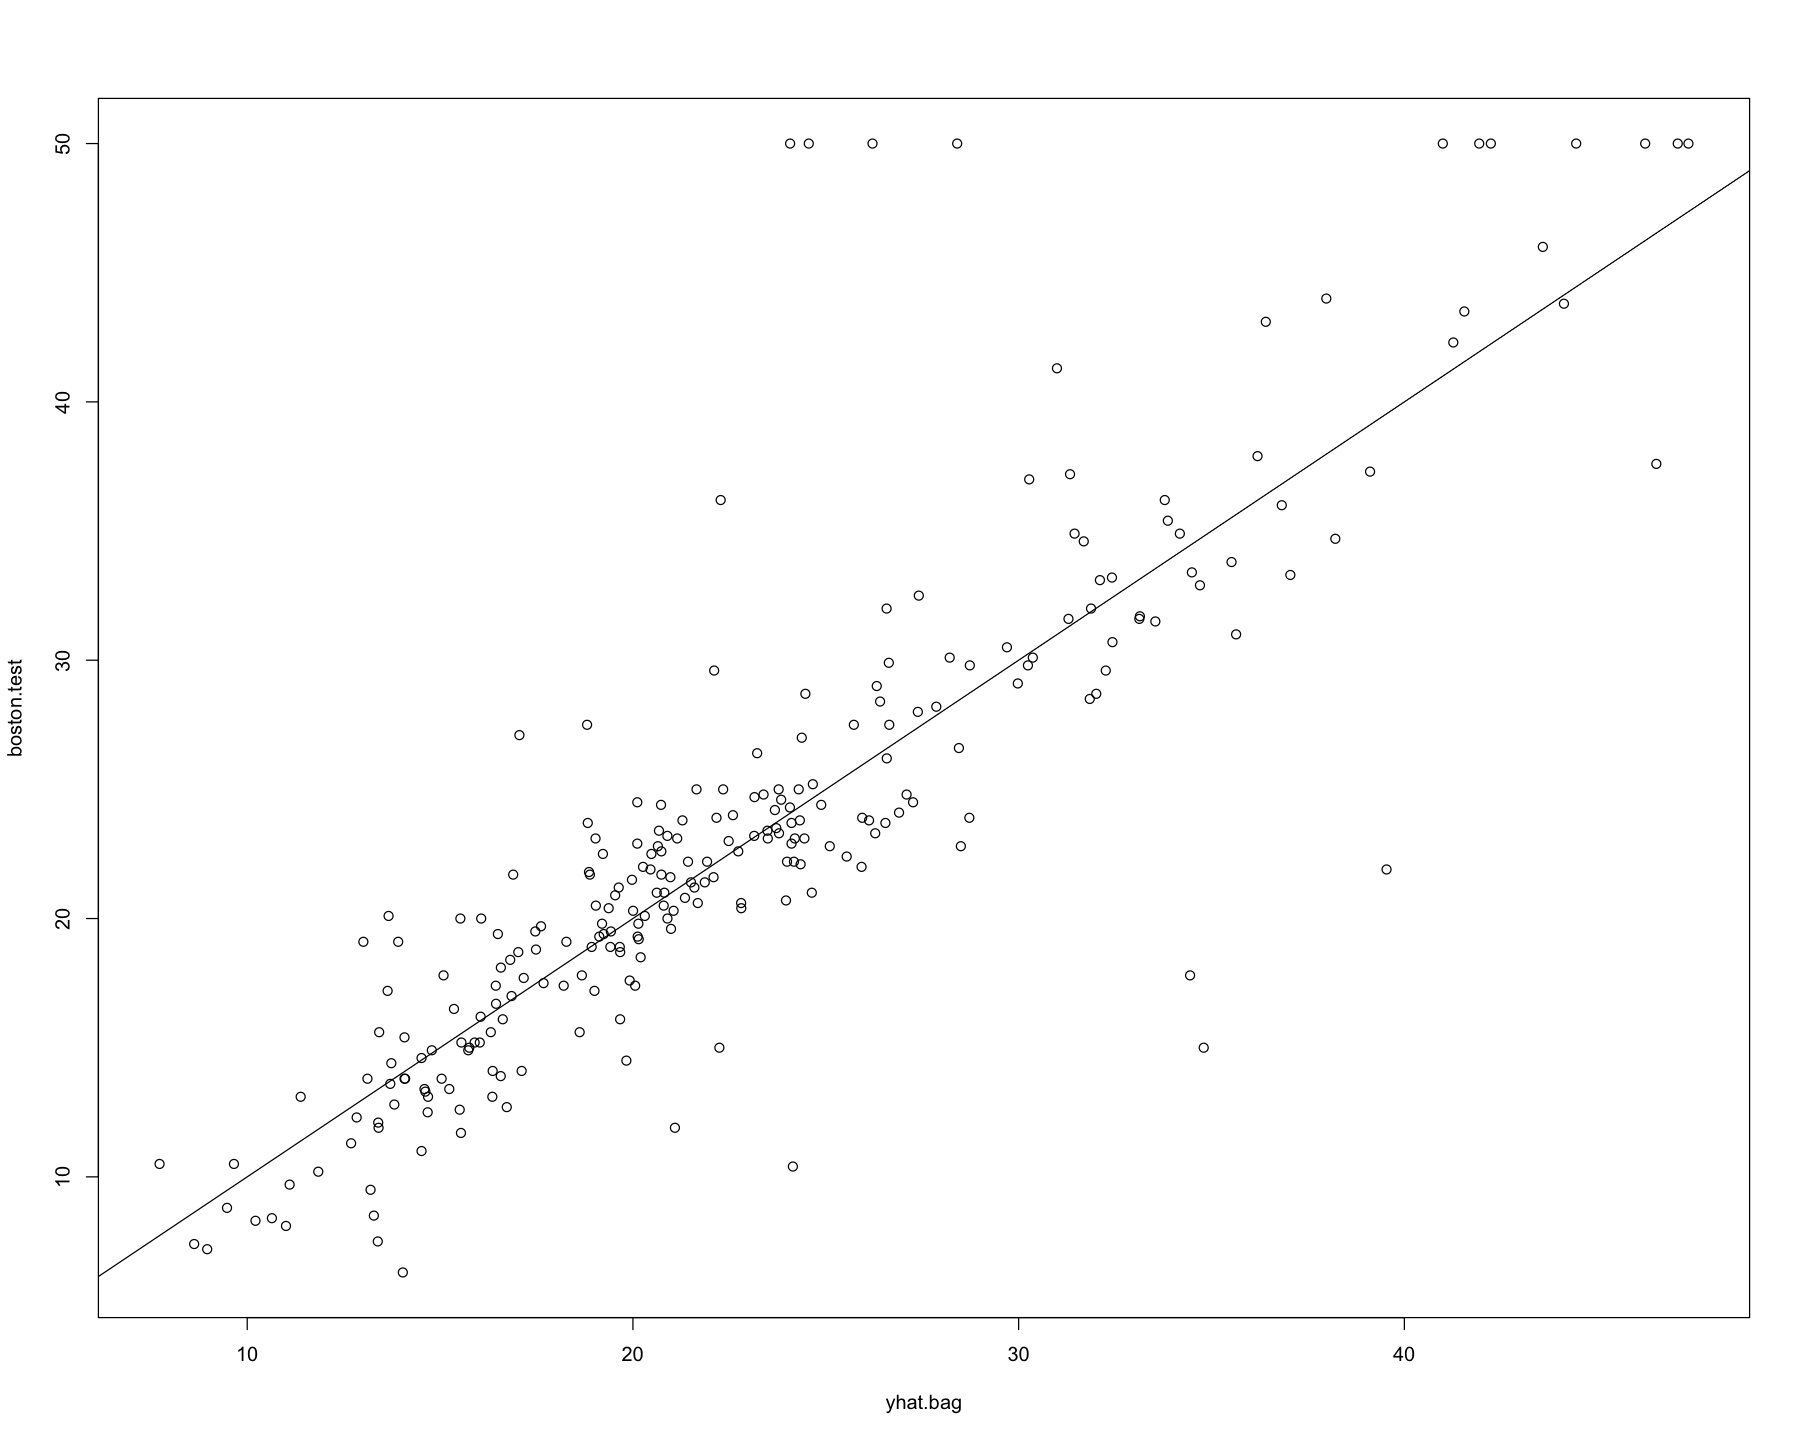

In [31]:
yhat.bag = predict(bag.boston, newdata = Boston[-train ,])
plot(yhat.bag, boston.test)
abline(0, 1)
mean((yhat.bag - boston.test)^2)

In [33]:
bag.boston = randomForest(medv ~ ., data = Boston,
    subset = train, mtry = 12, ntree = 25)
yhat.bag = predict(bag.boston , newdata = Boston[-train , ])
mean((yhat.bag - boston.test)^2)

[1] 25.75055

In [35]:
set.seed (1)
rf.boston = randomForest(medv ~ ., data = Boston,
    subset = train , mtry = 6, importance = TRUE )
yhat.rf = predict(rf.boston , newdata = Boston[-train,])
mean((yhat.rf - boston.test)^2)

[1] 20.06644

In [36]:
importance(rf.boston)

,%IncMSE,IncNodePurity
crim,19.435587,1070.42307
zn,3.091630,82.19257
indus,6.140529,590.09536
chas,1.370310,36.70356
nox,13.263466,859.97091
rm,35.094741,8270.33906
age,15.144821,634.31220
dis,9.163776,684.87953
rad,4.793720,83.18719
tax,4.410714,292.20949


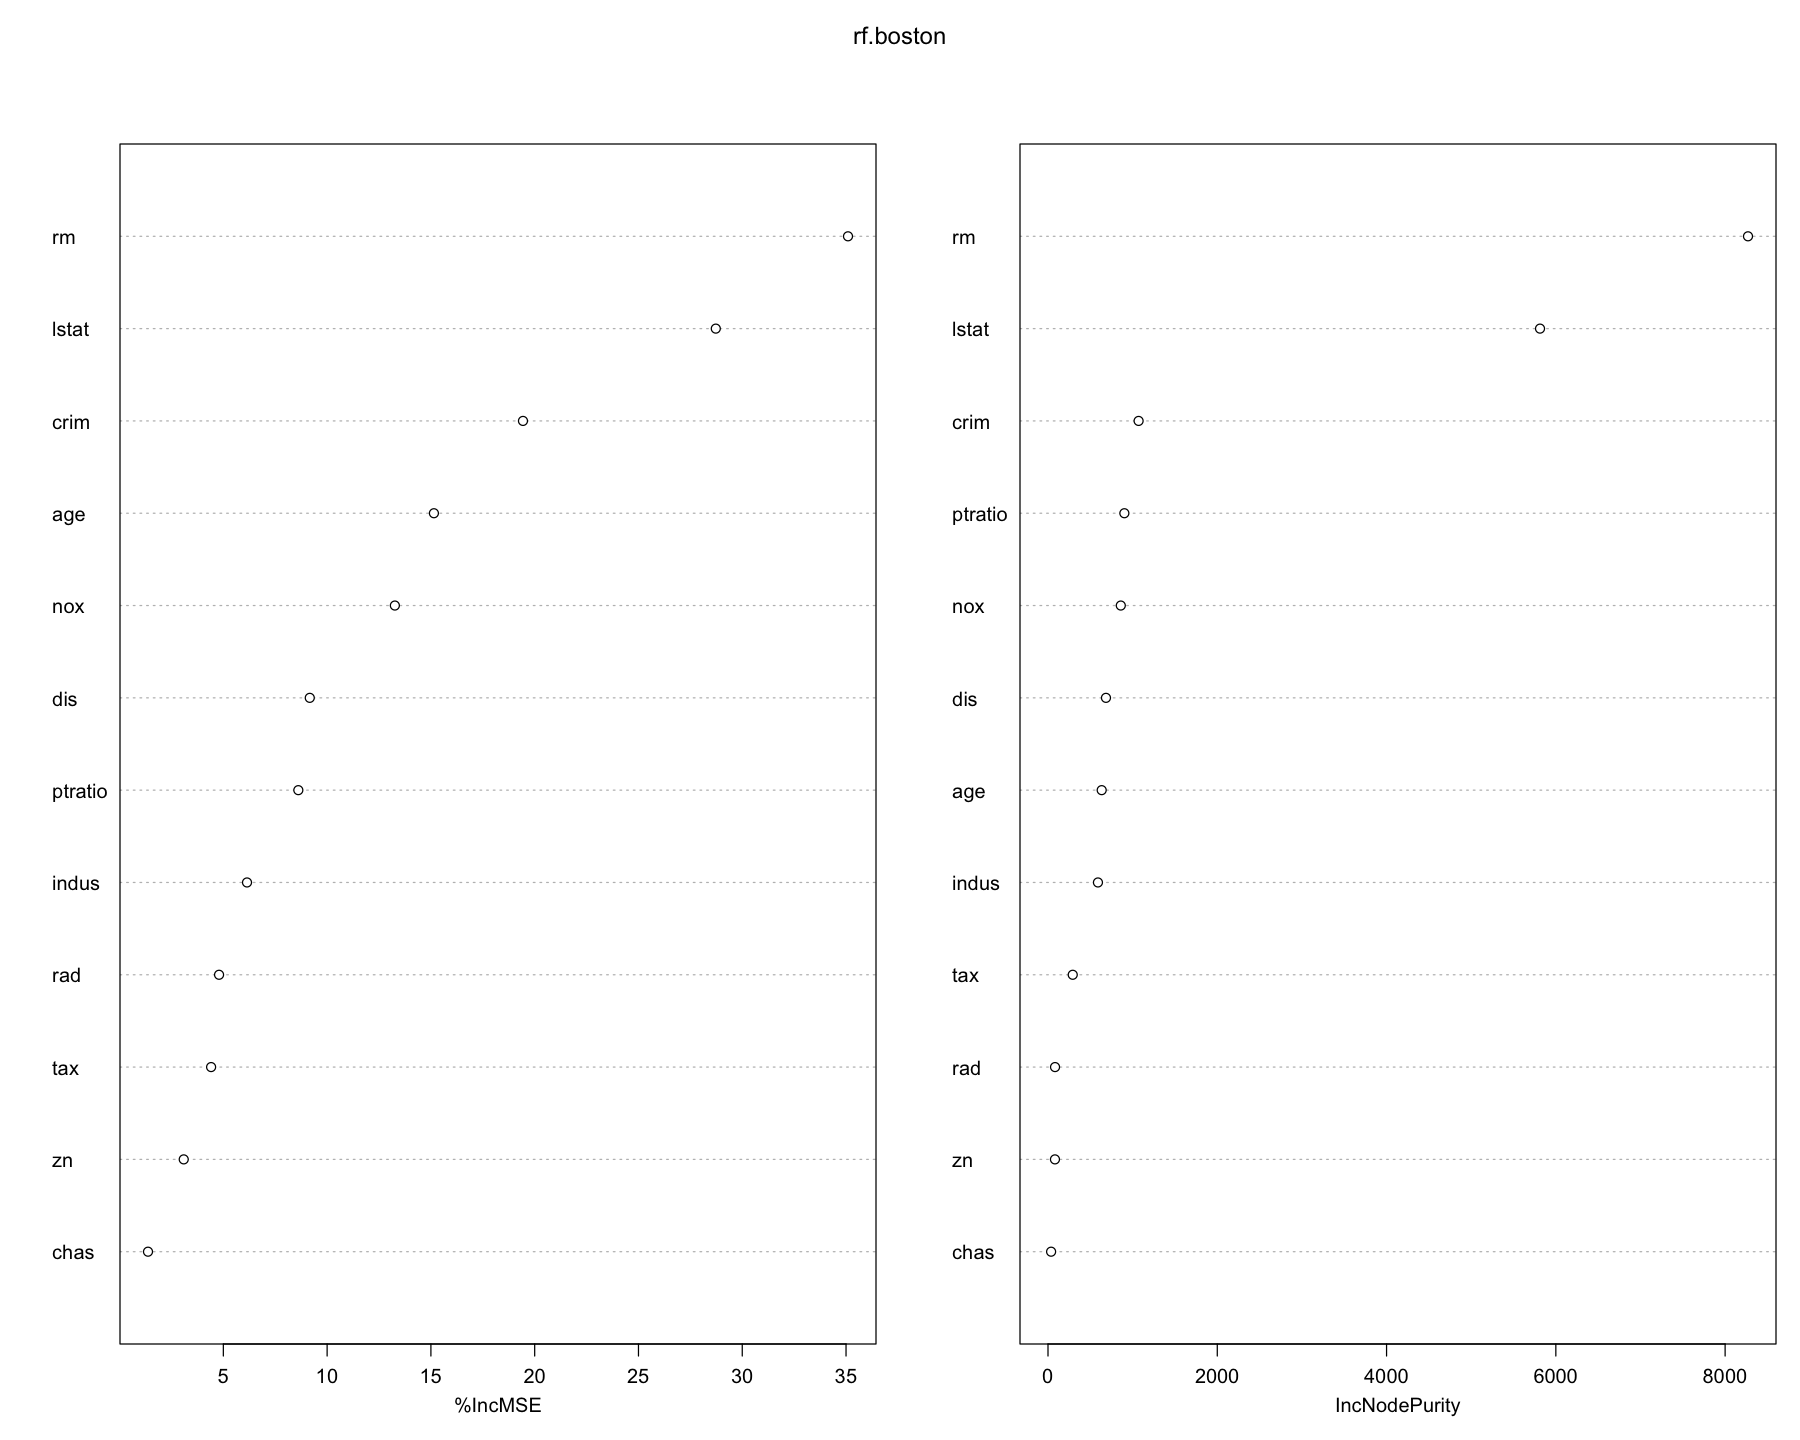

In [37]:
varImpPlot(rf.boston)

In [39]:
library(gbm)

Loaded gbm 2.2.3

This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3



,var,rel.inf
,<chr>,<dbl>
rm,rm,44.48249588
lstat,lstat,32.70281223
crim,crim,4.85109954
dis,dis,4.48693083
nox,nox,3.75222394
age,age,3.19769210
ptratio,ptratio,2.81354826
tax,tax,1.54417603
indus,indus,1.03384666


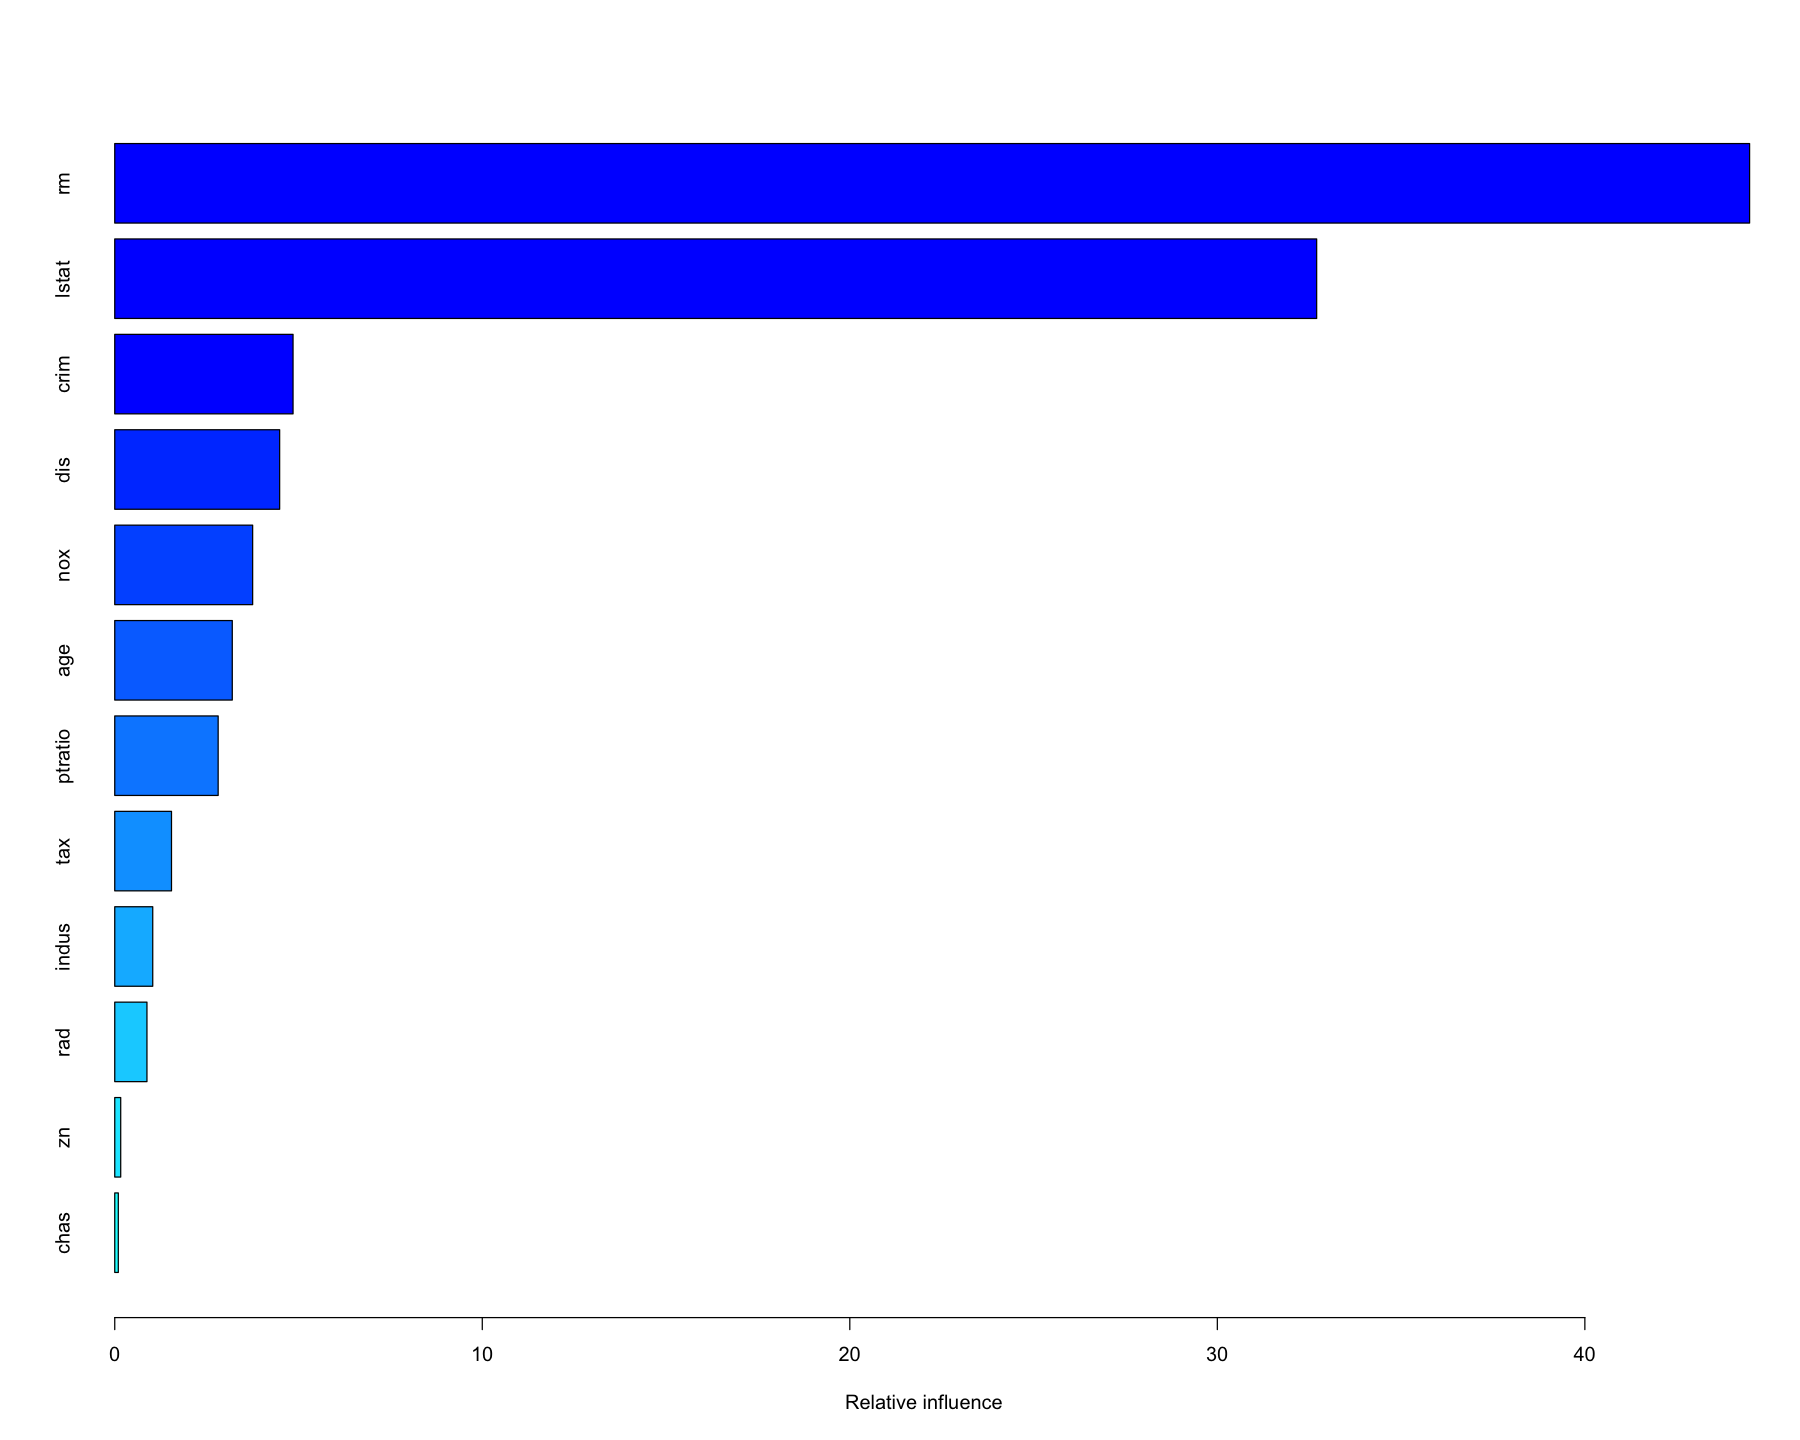

In [41]:
set.seed(1)
boost.boston = gbm(medv ~ ., data = Boston[train,],
    distribution = "gaussian", n.trees = 5000,
    interaction.depth = 4)
summary(boost.boston)

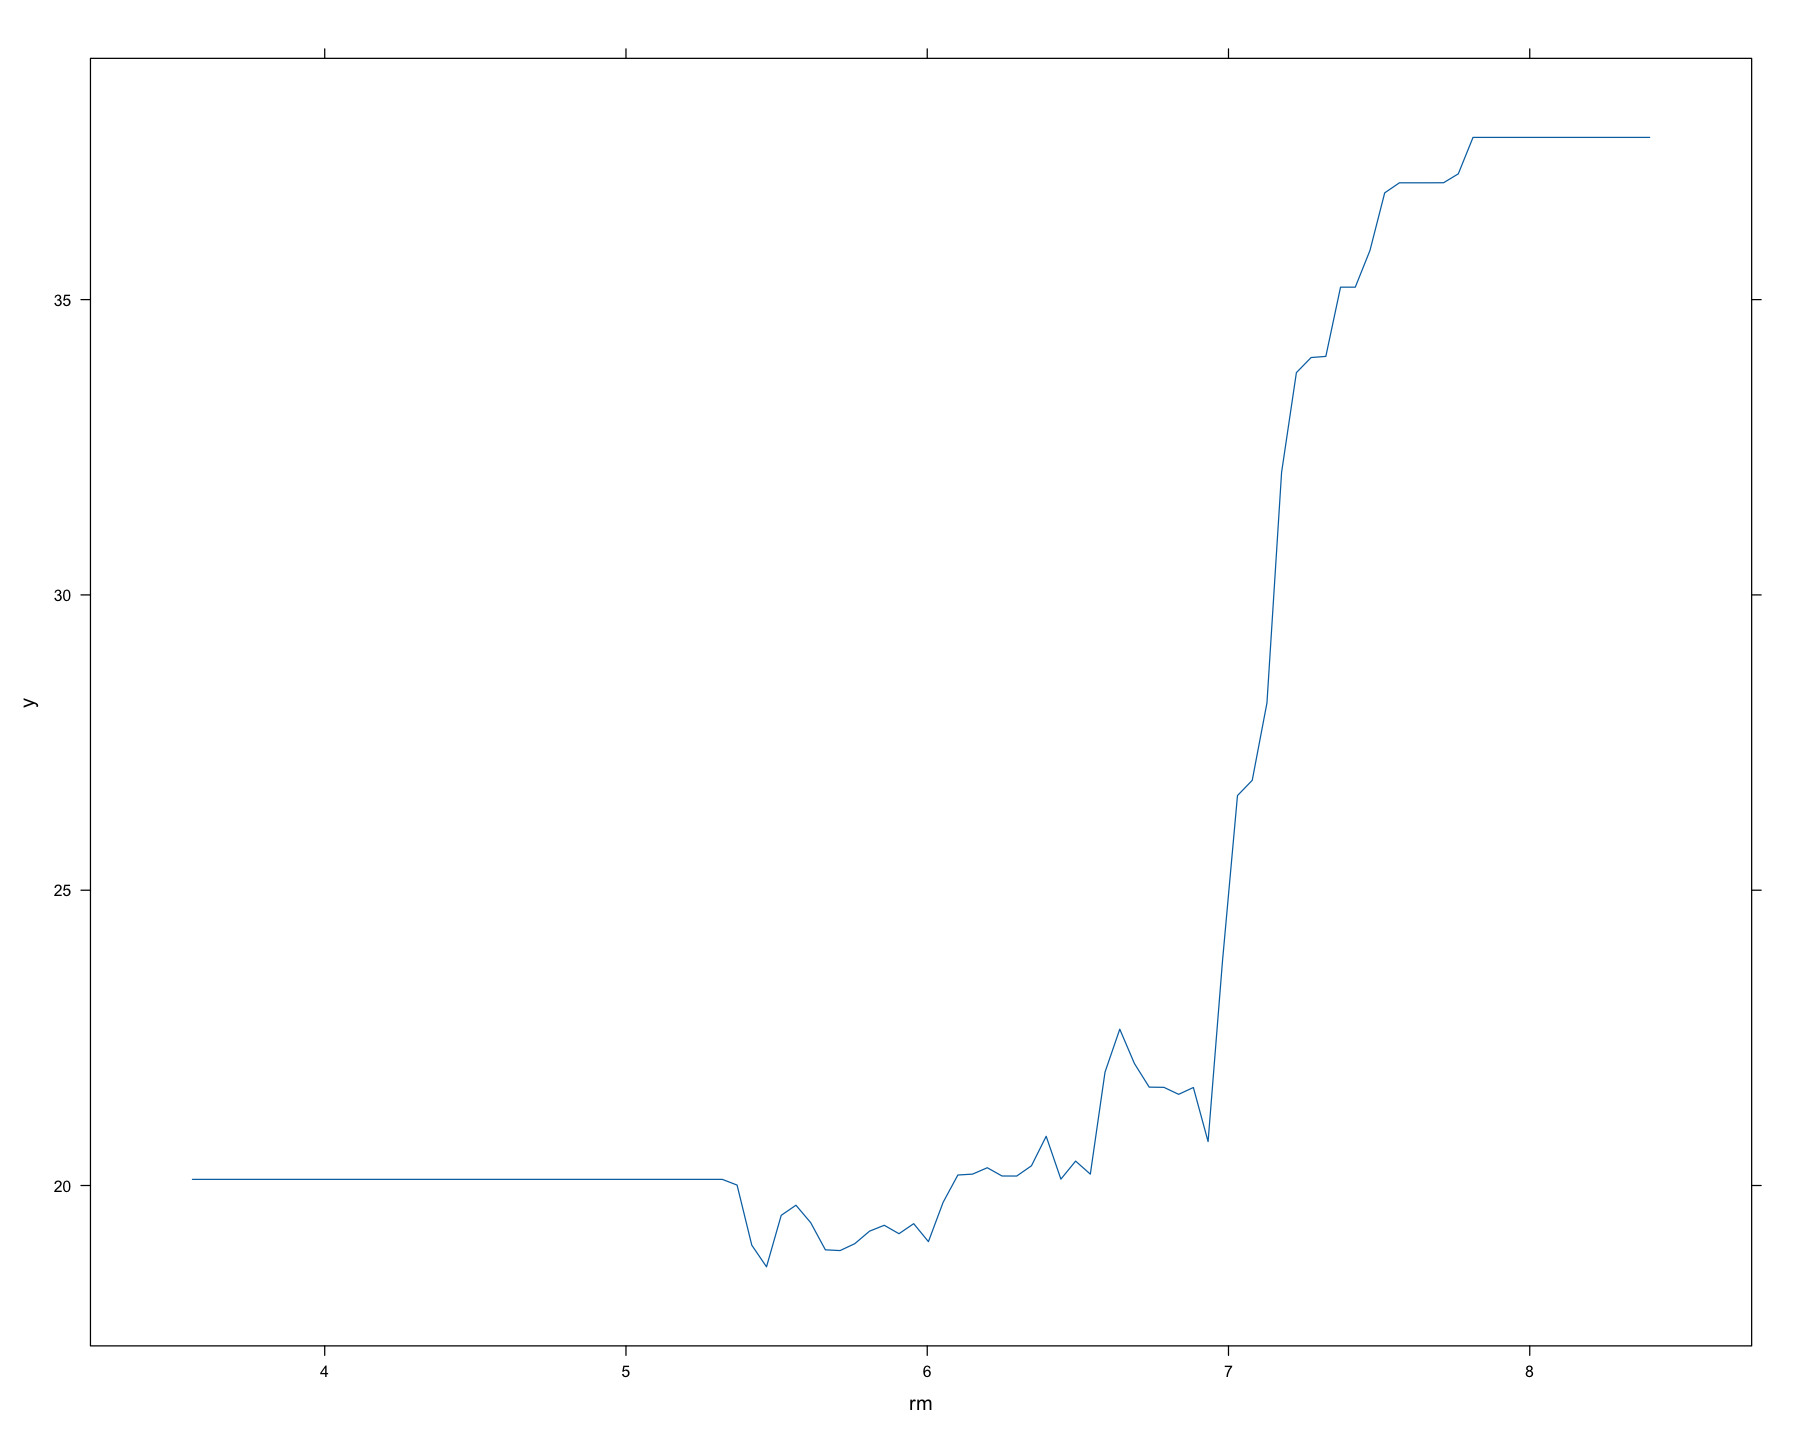

In [42]:
plot(boost.boston, i ="rm")

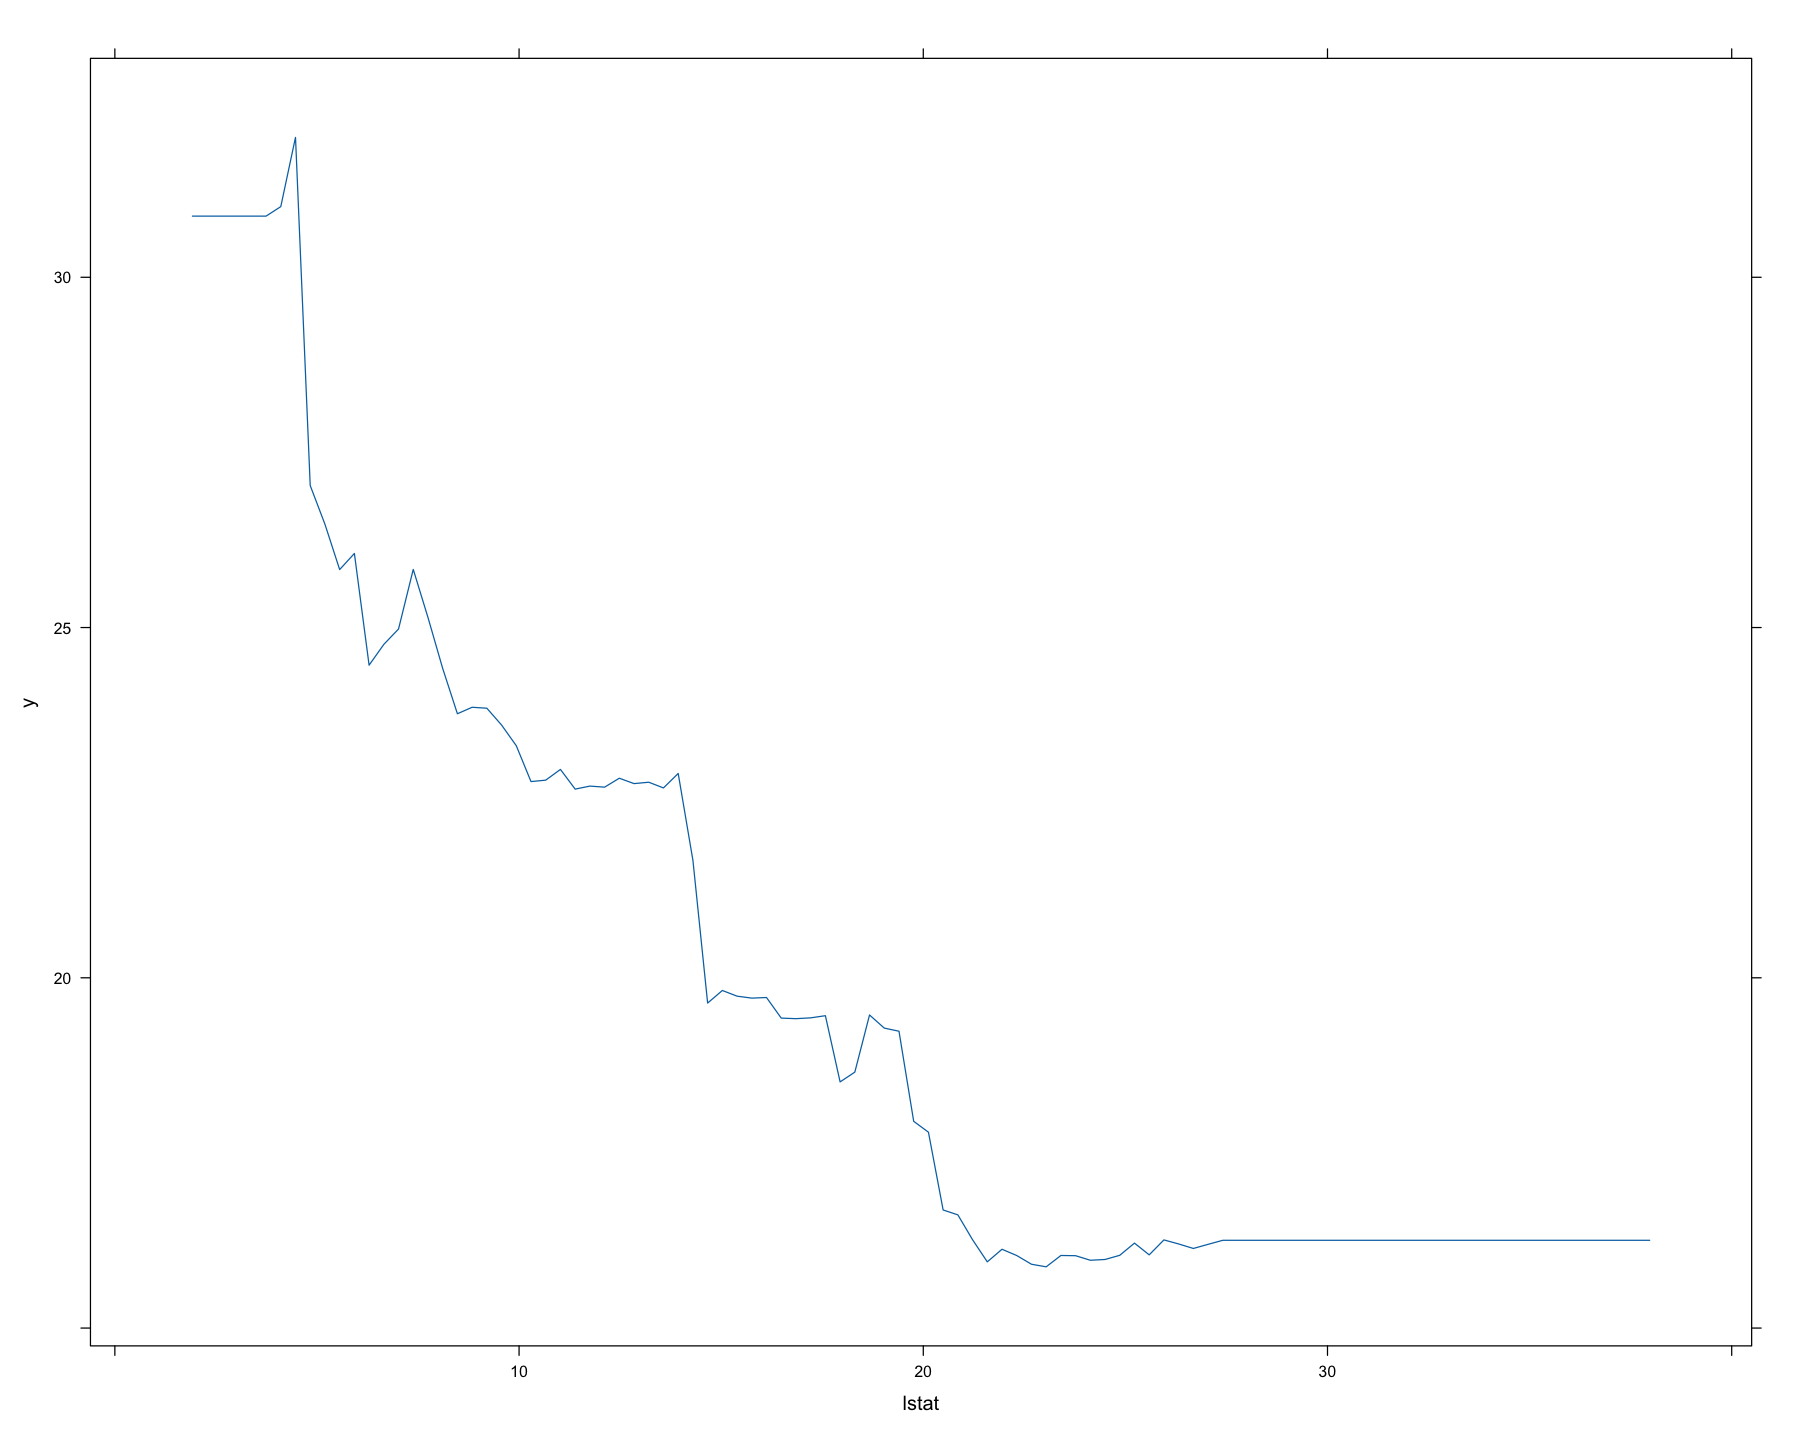

In [43]:
plot(boost.boston, i ="lstat")

In [44]:
yhat.boost = predict(boost.boston, newdata = Boston[-train,], n.trees = 5000)
mean((yhat.boost - boston.test)^2)

[1] 18.39057

In [45]:
boost.boston = gbm(medv ~ ., data = Boston[train, ],
    distribution = "gaussian", n.trees = 5000 ,
    interaction.depth = 4, shrinkage = 0.2, verbose = F)
yhat.boost = predict(boost.boston, newdata = Boston[-train, ], n.trees = 5000)
mean((yhat.boost - boston.test)^2)

[1] 17.39397

In [47]:
library(BART)

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


Loading required package: survival



In [48]:
x <- Boston[, 1:12]
y = Boston[, "medv"]
xtrain = x[train , ]
ytrain = y[train]
xtest = x[-train, ]
ytest = y[-train]
set.seed(1)
bartfit <- gbart(xtrain, ytrain, x.test = xtest)

*****Calling gbart: type=1
*****Data:
data:n,p,np: 253, 12, 253
y1,yn: 0.213439, -5.486561
x1,x[n*p]: 0.109590, 20.080000
xp1,xp[np*p]: 0.027310, 7.880000
*****Number of Trees: 200
*****Number of Cut Points: 100 ... 100
*****burn,nd,thin: 100,1000,1
*****Prior:beta,alpha,tau,nu,lambda,offset: 2,0.95,0.795495,3,3.71636,21.7866
*****sigma: 4.367914
*****w (weights): 1.000000 ... 1.000000
*****Dirichlet:sparse,theta,omega,a,b,rho,augment: 0,0,1,0.5,1,12,0
*****printevery: 100

MCMC
done 0 (out of 1100)
done 100 (out of 1100)
done 200 (out of 1100)
done 300 (out of 1100)
done 400 (out of 1100)
done 500 (out of 1100)
done 600 (out of 1100)
done 700 (out of 1100)
done 800 (out of 1100)
done 900 (out of 1100)
done 1000 (out of 1100)
time: 2s
trcnt,tecnt: 1000,1000


In [49]:
yhat.bart = bartfit$yhat.test.mean
mean((ytest - yhat.bart)^2)

[1] 15.91912

In [51]:
ord = order(bartfit$varcount.mean, decreasing = T)
bartfit$varcount.mean [ord]

nox   lstat     rad      rm     tax ptratio    chas     age   indus      zn 
 22.973  21.653  21.638  20.725  20.021  19.615  19.283  19.278  19.073  15.576 
    dis    crim 
 13.800  11.607